# Imports

In [2]:
import os
import utils
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import ceinms
import openSim
import pandas as pd
import shutil

def find_non_zero_mom_arm_muscles(ma_data, muscles):
    non_zero_muscles = []
    for muscle in muscles:
        if muscle not in ma_data.columns:
            continue
        if ma_data[muscle].abs().sum() > 0:
            non_zero_muscles.append(muscle)
    return non_zero_muscles

# utils.Organise().open_dir_in_explorer()

# Preprocessing

In [ ]:


def copy_input_files(src_session_path, dest_session_path, trial_list):
    """
    Copy necessary input files from source trial to destination trial.
    """
    input_files = [
        'trial_settings.xml',
    ]
    
    for trial in trial_list:
        src_trial_path = os.path.join(src_session_path, trial)
        dest_trial_path = os.path.join(dest_session_path, trial)
        
        os.makedirs(dest_trial_path, exist_ok=True)
        
        for file_name in input_files:
            src_file = os.path.join(src_trial_path, file_name)
            dest_file = os.path.join(dest_trial_path, file_name)
            if os.path.exists(src_file):
                shutil.copy2(src_file, dest_file)
                print(f"Copied {src_file} to {dest_file}")
            else:
                print(f"Warning: {src_file} does not exist and was not copied.")

src_session = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31')
dest_session = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_Katya', '25_03_31')
trials_to_copy = ['Squat_35kg_01', 'Squat_bw_01', 'Walking_02']

copy_input_files(src_session, dest_session, trials_to_copy)

# Single trial analysis

## Initiate trial

In [ ]:
subject = 'Athlete_03_Lernagopal' # 'Athlete_03', 'Athlete_03_MRI_BG'  'Athlete_03_MRI_Katya' Athlete_03_Lernagopal
session = '25_03_31' # '25_03_31' '22_07_06' walking
trial = 'Walking_02'  # 'Walking_02', 'Squat_35kg_01', 'Squat_bw_01'

trialPath = os.path.join(utils.SIMULATIONS_DIR, subject, session, trial) # Walking_02, Squat_bw_01, Squat_35kg_01
print(f'Analyzing trial at path: {trialPath}')

analysis = utils.Analyse(trialPath)
# analysis.reset_settings_xml()
# print main inputs
print("Main inputs:")
print(f"Model file: {analysis.model_dir}")
print(f"time range: {analysis.time_range}")

analysis.update_trial_attribute('Target_Muscles', 'all')
analysis.delete_trial_attribute('EMG_muscle_mapping')
analysis.delete_trial_attribute('Objective_Functions')

# set model to increased 3.00
# model_path = os.path.join(utils.MODELS_DIR, subject, session, 'scaled_model_P54.osim')
# analysis.update_model(model_path)
# analysis.load_settings(analysis.settingsXML)

# open settings.xml in the editor
settings_xml_path = os.path.join(trialPath, 'trial_settings.xml')
os.startfile(settings_xml_path)

## reload settings

In [ ]:

analysis.load_settings(analysis.settingsXML)
print(f'{analysis.model_dir}')

## manual steps

In [ ]:
# rename external loads file
shutil.move(os.path.join(trialPath, 'externalloads.xml'), os.path.join(trialPath, 'GRF.xml'))

## Export C3D

In [ ]:
analysis.export_c3d()

## Optimise model (modonese)

In [ ]:
analysis.model_dir

In [ ]:
coordinates_to_lock = ['knee_adduction_r', 'med_cond_adduction_r', 'lat_cond_adduction_r', 'knee_adduction_l', 'med_cond_adduction_l', 'lat_cond_adduction_l']
save_path = analysis.model_dir.replace('.osim', '_lockedCoords.osim')   

openSim.lock_model_coordinates(analysis.model_dir, coordinates_to_lock=coordinates_to_lock, save_path=save_path)

# check that the coordinates are locked in the model file
model = openSim.osim.Model(save_path)
for coord_name in coordinates_to_lock:
    coord = model.getCoordinateSet().get(coord_name)
    if coord.get_locked():
        print(f"Coordinate '{coord_name}' is locked as expected.")
    else:
        print(f"Error: Coordinate '{coord_name}' is not locked.")

In [ ]:
import muscleOptimizer

muscleOptimizer.main(osim_model_targ_filepath=analysis.model_dir,
                     osim_model_ref_filepath=os.path.join(utils.MODELS_DIR, 'Catelli-V4.0_PowerliftingMarkers.osim'))

## Increase model isometric force

In [ ]:
analysis.increase_muscle_force(factor=3.0)

## Run IK

In [ ]:
analysis.replace = True
analysis.run_ik()
analysis.plot_ik()


## run id

In [ ]:
analysis.run_id()
analysis.plot_id()

## run ma

In [ ]:
analysis.replace = True
analysis.run_ma()

## run so

In [ ]:
analysis.replace = True
# model_path = os.path.join(utils.MODELS_DIR, subject, session, 'scaled_opt_N10_increased_3.00.osim')
# analysis.update_model(model_path)
analysis.load_settings(analysis.settingsXML)
analysis.run_so()

## run jra

In [ ]:
analysis.replace = True
analysis.run_jra()

## emg normalise / scale / plot

In [ ]:
analysis.run_emg_normalise()

In [ ]:
analysis.scale_emg(scale_factor=0.70)

In [ ]:
analysis.plot_emg()

## Create ceinms setup files

In [ ]:
analysis.create_ceinms_input_data()

In [ ]:
analysis.replace = False

analysis.create_ceinms_model()

analysis.create_ceinms_calibration_cfg(calibration_trial_names=['Walking03'])

analysis.create_ceinms_calibration_setup()


In [ ]:
analysis.replace = False
analysis.create_excitation_generator()

## ceinms calibration

In [ ]:
setupXML_path = os.path.join(analysis.path, analysis.ceinms_calibration_setup)
ceinms.calibrate(setupXML_path)

In [ ]:
ceinms.plot_ceinms_calibration_results(setupXML_path=setupXML_path)

In [ ]:
setupXML = ET.parse(setupXML_path).getroot()

ucalibrated_model_name = setupXML.find('subjectFile').text
uncalibrated_model_path = os.path.relpath(os.path.join(os.path.dirname(setupXML_path), ucalibrated_model_name), analysis.path)

calibrated_model_name = setupXML.find('outputSubjectFile').text
calibrated_model_path = os.path.relpath(os.path.join(os.path.dirname(setupXML_path), calibrated_model_name), analysis.path)


ceinms.plot_ceinms_model_parameters(ceinmsModelPath=calibrated_model_path)

ceinms.plot_compare_ceinms_models(uncalibratedModelPath=uncalibrated_model_path, calibratedModelPath=calibrated_model_path)

In [ ]:
ceinms.plot_compare_ceinms_models(uncalibratedModelPath=os.path.join(analysis.path, '..\subjectUncalibrated.xml'), calibratedModelPath=os.path.join(analysis.path, '..\subjectCalibrated.xml'))

## ceinms exe and optimise setups

In [ ]:
# print ceinms settings
print('CEIMS Settings:')
print(f'alpha: {analysis.alpha}')
print(f'beta: {analysis.beta}')
print(f'gamma: {analysis.gamma}')
print(f'ceinms_exe_dir: {analysis.ceinms_exe_dir}')

In [ ]:
analysis.create_ceinms_exe_cfg()

analysis.create_ceinms_exe_setup()

In [ ]:
analysis.create_ceinms_optimise_setup()

In [ ]:
analysis.create_ceinms_cfg_from_excitation_generator()

## check excitation generator

In [ ]:
analysis.prepare_excitations_for_ceinms()

## run ceinms exe

In [ ]:
analysis.run_ceinms_exe()

## ceinms optimise

In [ ]:
analysis.run_ceinms_optimise()

In [ ]:
ceinms.plot_optimisation_results(analysis.ceinms_optimisation_dir)

ceinms_excitations = os.path.join(analysis.ceinms_optimisation_dir, 'AdjustedEmgs.sto')
ceinms_torques = os.path.join(analysis.ceinms_optimisation_dir, 'Torques.sto')

ceinms.plot_experimental_vs_ceinms(emgFile=analysis.emg_normalised, ceinmsExcitationsFile=ceinms_excitations, excitationGeneratorFile=analysis.ceinms_excitation_generator, externalMomentsFile=analysis.id,ceinmsTorquesFile=ceinms_torques)

## Add SO columns to CEINMS forces

In [ ]:
analysis.load_settings(analysis.settingsXML)

In [ ]:
analysis.load_settings(analysis.settingsXML)
analysis.update_trial_attribute('jra_forces_ceinms', 'Execution_a1_b1_g1000\\MuscleForces.sto')
analysis.load_settings(analysis.settingsXML)

In [ ]:
analysis.add_so_columns_to_ceinms_results()

## Add SO activations to EMG to create fully driven analysis

In [ ]:
# Add SO activations as EMG inputs and create new excitation generator file with all muscles there for new CEINMS run

# Load SO activations
so_activations = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_activations))

# Load existing EMG data
emg_data = utils.load_any_data_file(os.path.join(analysis.path, analysis.emg_normalised))

# Find muscles in SO that are not in EMG
missing_muscles = [col for col in so_activations.columns if col not in emg_data.columns and col != 'time']

# Create combined activation data starting with EMG
combined_activations = emg_data.copy()

# Add missing muscle activations from SO
for muscle in missing_muscles:
    combined_activations[muscle] = so_activations[muscle]
    print(f"Added {muscle} from SO activations")

# Save combined activations file
combined_emg_path = os.path.join(analysis.path, analysis.emg_normalised).replace('.sto', '_with_SO.sto')
utils.write_sto_file(combined_activations, combined_emg_path)
print(f"Saved combined activations to: {combined_emg_path}")

# Update excitation generator to include all muscles
analysis.update_trial_attribute('emg_normalised', os.path.basename(combined_emg_path))
analysis.create_excitation_generator()
print(f"Updated excitation generator with all muscles")

## JRA ceinms 

In [ ]:
analysis.replace = True
new_model = os.path.join(utils.MODELS_DIR, subject, session, 'scaled_opt_N10.osim')
analysis.update_model(new_model)
analysis.run_jra_ceinms()

## JRA 

In [ ]:
new_model = os.path.join(utils.MODELS_DIR, subject, session, 'scaled_opt_N10_increased_3.00.osim')
analysis.update_model(new_model)
analysis.update_trial_attribute('jra', 'Analyse_JRA_ReactionLoads_SO.sto')
analysis.run_jra()


## Compare SO and CEINMS (activations, force, emg)

In [ ]:
so_forces = utils.load_any_data_file(analysis.jra_forces)
ceinms_forces = utils.load_any_data_file(analysis.jra_forces_ceinms)

so_activations = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_activations))
ceinms_activations = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms.replace('MuscleForces.sto', 'Activations.sto')))

so_lengths = utils.load_any_data_file(os.path.join(analysis.path, analysis.ma, '_MuscleAnalysis_NormalizedFiberLength.sto'))
ceinms_lengths = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms.replace('MuscleForces.sto', 'NormFibreLengths.sto')))

emg = utils.load_any_data_file(os.path.join(analysis.path, analysis.ceinms_excitations))
emg = emg[emg['time'].isin(so_activations['time'])]


excitation_mapping = ET.parse(os.path.join(analysis.path, analysis.ceinms_excitation_generator)).getroot()

labels = {'SO':'SO Forces', 'CEINMS':'CEINMS Forces'}
lineStyles = {'SO':'-', 'CEINMS':'--'}
colors = {'SO':'tab:blue', 'CEINMS':'tab:orange'}

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

def get_emg_signals_for_muscle_groups(analysis: utils.Analyse, muscles: list):

    signals = []
    for muscle in muscles:
        signal = analysis.get_muscle_excitation_mapping(muscle)
        
        if signal:
            signals.append(signal)

    # Flatten the list and delete duplicate signals after processing all muscles
    if signals:
        # Flatten list of lists to a single list
        flattened_signals = [item for sublist in signals for item in (sublist if isinstance(sublist, list) else [sublist])]
        # Remove duplicates
        signals = list(set(flattened_signals))
    
    return signals

n_cols = 5
n_rows = len(muscleGroups) // n_cols + (len(muscleGroups) % n_cols > 0)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Muscle Force Comparison SO vs CEINMS', fontsize=16)

for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    row = count // n_cols
    col_name = count % n_cols
    ax = ax.flatten()
    
    # SO forces and activations
    sum_forces = so_forces[muscles].sum(axis=1)
    ax[count].plot(so_forces['time'], sum_forces, label=labels['SO'], color=colors['SO'])

    # CEINMS forces and activations
    sum_forces = ceinms_forces[muscles].sum(axis=1)
    ax[count].plot(ceinms_forces['time'], sum_forces, label=labels['CEINMS'], color=colors['CEINMS'], linestyle=lineStyles['CEINMS'])
    ax[count].set_title(f'{muscleGroup}')

    if count == 0:
        ax[count].legend(loc='upper right')


save_path = os.path.join(analysis.path, 'muscle_force_comparison.png')
fig.savefig(save_path)
print(f'Saved figure to {save_path}')


# Activations
n_cols = 5
n_rows = len(muscleGroups) // n_cols + (len(muscleGroups) % n_cols > 0)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Muscle Activations Comparison SO vs CEINMS', fontsize=16)

for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    row = count // n_cols
    col_name = count % n_cols
    ax = ax.flatten()

    emg_labels = get_emg_signals_for_muscle_groups(analysis, muscles)
    
    # SO ctivations
    ax1 = ax[count]
    
    ax1.plot(so_activations['time'], so_activations[muscles].mean(axis=1), color=colors['SO'], alpha=0.3, linewidth=2, label='SO Activations', linestyle=lineStyles['SO'])

    # CEINMS activations
    ax1.plot(ceinms_activations['time'], ceinms_activations[muscles].mean(axis=1), color=colors['CEINMS'], alpha=0.3, linewidth=2, label='CEINMS Activations', linestyle=lineStyles['CEINMS'])
    ax1.set_title(f'{muscleGroup}')
    
    # EMG in a grey path for reference
    if len(emg_labels) > 0:
        ax1.fill_between(emg['time'], 0, emg[emg_labels].mean(axis=1), color='gray', alpha=0.2, label='EMG')
        ax1.plot(emg['time'], emg[emg_labels].mean(axis=1), color='gray', linewidth=2)

        # calculare r2 and RMSE between SO and CEINMS activations and EMG
        rmse_so = utils.rmse(so_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
        r2_so = utils.rsquared(so_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
        rmse_ceinms = utils.rmse(ceinms_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
        r2_ceinms = utils.rsquared(ceinms_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))

        # Add text box with RMSE and R2 values
        if len(emg_labels) > 0:
            textstr = f'SO: RMSE={rmse_so:.3f}, R²={r2_so:.3f}\nCEINMS: RMSE={rmse_ceinms:.3f}, R²={r2_ceinms:.3f}'
            ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=8,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    if count == 0:
        ax1.legend(loc='upper left', bbox_to_anchor=(0.5, 1.5), framealpha=0.9)

save_path = os.path.join(analysis.path, 'muscle_activation_comparison.png')
fig.savefig(save_path)
print(f'Saved figure to {save_path}')


# Fiber Lengths
n_cols = 5
n_rows = len(muscleGroups) // n_cols + (len(muscleGroups) % n_cols > 0)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Muscle Fiber Length Comparison SO vs CEINMS', fontsize=16)


for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    row = count // n_cols
    col_name = count % n_cols
    ax = ax.flatten()
    
    # SO fiber lengths
    mean_lengths = so_lengths[muscles].mean(axis=1)
    ax[count].plot(so_lengths['time'], mean_lengths, label=labels['SO'], color=colors['SO'])

    # CEINMS fiber lengths
    mean_lengths = ceinms_lengths[muscles].mean(axis=1)
    ax[count].plot(ceinms_lengths['time'], mean_lengths, label=labels['CEINMS'], color=colors['CEINMS'], linestyle=lineStyles['CEINMS'])
    ax[count].set_title(f'{muscleGroup}')

    if count == 0:
        ax[count].legend(loc='upper right')

save_path = os.path.join(analysis.path, 'muscle_fiber_length_comparison.png')
fig.savefig(save_path)
print(f'Saved figure to {save_path}')

In [ ]:
# r2_so = utils.rsquared(so_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
emg[emg_labels].mean(axis=1)
# so_activations[muscles].mean(axis=1)

## Compare muscle moments 

In [ ]:
ik_columns = ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'ankle_angle_r']
id_columns = ['hip_flexion_r_moment', 'hip_adduction_r_moment', 'hip_rotation_r_moment', 'knee_angle_r_moment', 'ankle_angle_r_moment']

id = utils.load_any_data_file(os.path.join(analysis.path, analysis.id))
so_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_forces))


fig, ax = plt.subplots(nrows=len(ik_columns), ncols=3, figsize=(40, 15))
count = -1
for dof in ik_columns:

    count += 1
    ma = utils.load_any_data_file(os.path.join(analysis.path, analysis.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))

    muscle_list = [col for col in so_forces.columns if col != 'time']
    muscles = find_non_zero_mom_arm_muscles(ma, muscle_list)
    print(f"Non-zero moment arm muscles for {dof}: {muscles}")

    if count == 0:
        ax[count, 0].set_title('Scaled')
        ax[count, 1].set_title('BG')
        ax[count, 2].set_title('Katya')

    # Plot id 
    ax[count, 0].plot(id['time'], id[f'{dof}_moment'], label='ID', color='blue')

    ax[count, 0].set_ylabel(f'{dof} Moment (Nm)')

    # Plot muscle moments
    muscle_moment = (so_forces[muscles] * ma[muscles])
    ax[count, 0].plot(so_forces['time'], muscle_moment, label=muscles, color='red', linestyle='--')




    
plt.tight_layout()
save_path = os.path.join(analysis.path, f'muscle_moments_so_{trialName}.png')
plt.savefig(save_path)
print(f"Inverse dynamics comparison plot saved: {save_path}")
    

## Compare JRA SO and CEINMS

In [ ]:
jra_Scaled_so = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra))
jra_Scaled_ceinms = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_ceinms))

fig, ax = plt.subplots(3,   4, figsize=(15, 8))

labels = ['SO', 'CEINMS']
lineStyles = ['-', '--']
count = -1
for df in [jra_Scaled_so, jra_Scaled_ceinms]:
    count += 1
    
    # plot Hip first row    
    x = df['hip_r_on_femur_r_in_femur_r_fx']
    y = df['hip_r_on_femur_r_in_femur_r_fy']
    z = df['hip_r_on_femur_r_in_femur_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[0, 0].plot(df['time'], x, label=labels[count], linestyle=lineStyles[count])
    ax[0, 1].plot(df['time'], y, label=labels[count], linestyle=lineStyles[count])
    ax[0, 2].plot(df['time'], z, label=labels[count], linestyle=lineStyles[count])
    ax[0, 3].plot(df['time'], sum, label=labels[count], linestyle=lineStyles[count])
    
    ax[0, 0].set_ylabel(' Hip Force (N)')
    ax[0, 0].set_title('X (+ anterior, - posterior)')
    ax[0, 1].set_title('Y (+ medial, - lateral)')
    ax[0, 2].set_title('Z (+ superior, - inferior)')
    ax[0, 3].set_title('Resultant Force Magnitude')

    # plot Hip first row
    x = df['walker_knee_r_on_tibia_r_in_tibia_r_fx']
    y = df['walker_knee_r_on_tibia_r_in_tibia_r_fy']
    z = df['walker_knee_r_on_tibia_r_in_tibia_r_fz']

    sum = np.linalg.norm([x,y,z], axis=0)
    ax[1, 0].plot(df['time'], x, label=labels[count], linestyle=lineStyles[count])
    ax[1, 1].plot(df['time'], y, label=labels[count], linestyle=lineStyles[count])
    ax[1, 2].plot(df['time'], z, label=labels[count], linestyle=lineStyles[count])
    ax[1, 3].plot(df['time'], sum, label=labels[count], linestyle=lineStyles[count])

    ax[1, 0].set_ylabel(' Knee Force (N)')
    
    
    # plot Ankle last row
    x = df['ankle_r_on_talus_r_in_talus_r_fx']
    y = df['ankle_r_on_talus_r_in_talus_r_fy']
    z = df['ankle_r_on_talus_r_in_talus_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[2, 0].plot(df['time'], x, label=labels[count], linestyle=lineStyles[count])
    ax[2, 1].plot(df['time'], y, label=labels[count], linestyle=lineStyles[count])
    ax[2, 2].plot(df['time'], z, label=labels[count], linestyle=lineStyles[count])
    ax[2, 3].plot(df['time'], sum, label=labels[count], linestyle=lineStyles[count])

    ax[2, 0].set_ylabel(' Ankle Force (N)')
    
        

ax[0, 0].legend()
plt.tight_layout()
save_path = os.path.join(analysis.path, f'jra_so_vs_ceinms.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")
    



## push to git

In [ ]:
analysis.push_trial_results_to_git()

# Troubleshoot

In [ ]:
analysis.load_settings(analysis.settingsXML)
osim_modelPath = analysis.model_dir
ik_output = os.path.join(analysis.path, analysis.ik)
grf_xml = os.path.join(analysis.path, analysis.setup_grf)
setup_jra_xml = os.path.join(analysis.path, analysis.setup_jra)
actuators_xml = None
muscle_force_path = os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('MuscleForces', 'MuscleForces_updated')
saveFileName = os.path.join(analysis.path, "JRA_results.sto")

openSim.run_jra(osim_modelPath=osim_modelPath, 
                ik_output=ik_output, 
                grf_xml=grf_xml, 
                setup_xml=setup_jra_xml, 
                actuators=actuators_xml, 
                muscle_force_path=muscle_force_path, 
                saveFileName=saveFileName)

In [ ]:
setupXML_path = r'C:\Git\powerlifing_model\simulations\Athlete_03\25_03_31\Walking_02\ceinms_setup.xml'
ceinms.executable(setupXML_path)

## Compare multiple files

In [ ]:
filepath1 = os.path.join(analysis.path, analysis.jra)
filepath2 = os.path.join(analysis.path, analysis.jra_ceinms)
filepath3 = os.path.join(analysis.path, analysis.jra_ceinms).replace('MuscleForces', 'MuscleForces_updated')

files = {'so': utils.load_any_data_file(filepath1),
         'ceinms': utils.load_any_data_file(filepath2),
         'ceinms_with_SO_updated': utils.load_any_data_file(filepath3)}

results_dir = os.path.join(utils.RESULTS_DIR, 'compare')
os.makedirs(results_dir, exist_ok=True)

common_columns = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz', 'walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz', 'ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

nrows, ncols = utils.calculate_nRows_nCols(len(common_columns))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 6*nrows))

for file_key, data in files.items():
    print(f"{file_key} columns: {data.columns}")

    for idx, column in enumerate(common_columns):
        row = idx // ncols
        col_name = idx % ncols
        ax[row, col_name].plot(data['time'], data[column], label=file_key)
        ax[row, col_name].set_title(column)
        ax[row, col_name].set_xlabel('Time (s)')
        ax[row, col_name].set_ylabel('Value')
        ax[row, col_name].legend()
# plt.tight_layout()
save_path = os.path.join(results_dir, 'comparison_plot.png')

In [ ]:
# compare columns SO vs CEINMS forces
ceinms_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms))
so_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_forces))

for column in so_forces.columns:
    if not column in ceinms_forces.columns:
        print(f"Column {column} not found in CEINMS forces.")
        
        # add column to ceinms_forces with the same valuse as SO
        ceinms_forces[column] = so_forces[column]

utils.write_sto_file(ceinms_forces, os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('.sto', '_updated.sto'))
print(f"Saved updated CEINMS forces to {os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('.sto', '_updated.sto')}")
        

# Plots single trials MRI vs Linear scaled

## Initiate settings

In [ ]:
import matplotlib.pyplot as plt
import opensim as osim
ik_columns = ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'ankle_angle_r']
id_columns = ['hip_flexion_r_moment', 'hip_adduction_r_moment', 'hip_rotation_r_moment', 'knee_angle_r_moment', 'ankle_angle_r_moment']

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

subject_compare1 = 'Athlete_03'
subject2 = 'Athlete_03_MRI_BG'
session = '25_03_31'
trialName = 'Walking_02' # 'Walking_02', 'Squat_bw_01', 'Squat_35kg_01'

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

results_dir = os.path.join(utils.RESULTS_DIR, 'Compare_models')
os.makedirs(results_dir, exist_ok=True)

trialPath_scaled = os.path.join(utils.SIMULATIONS_DIR, subject_compare1, session, trialName)
trial_scaled = utils.Analyse(trialPath_scaled)

trialPath_MRI = os.path.join(utils.SIMULATIONS_DIR, subject2, session, trialName)
trial_MRI = utils.Analyse(trialPath_MRI)

model = osim.Model(trial_scaled.model_dir)
state = model.initSystem()
bodyMass = model.getTotalMass(state)

## IK

In [ ]:
ik_scaled = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.ik))
ik_MRI = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.ik))

fig, ax = plt.subplots(5,   1, figsize=(8, 10))
for col_name in ik_columns:
    ax_idx = ik_columns.index(col_name)
    ax[ax_idx].plot(ik_scaled['time'], ik_scaled[col_name], label=trial_scaled.subject, color=colors['scaled'])
    ax[ax_idx].plot(ik_MRI['time'], ik_MRI[col_name], label=trial_MRI.subject, color=colors['MRI_BG'])
    ax[ax_idx].set_title(col_name)   
    ax[ax_idx].set_ylabel('Angle (deg)')
    if ax_idx == 0:
        ax[ax_idx].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'ik_{trialName}.png')
plt.savefig(save_path)
print(f"IK comparison plot saved: {save_path}")


## ID

In [ ]:
id_scaled = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.id))
id_MRI = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.id))

fig, ax = plt.subplots(len(id_columns),   1, figsize=(8, 10))
for col_name in id_columns:
    ax_idx = id_columns.index(col_name)
    ax[ax_idx].plot(id_scaled['time'], id_scaled[col_name]/bodyMass, label=trial_scaled.subject, color=colors['scaled'])
    ax[ax_idx].plot(id_MRI['time'], id_MRI[col_name]/bodyMass, label=trial_MRI.subject, color=colors['MRI_BG'])
    ax[ax_idx].set_title(col_name)   
    ax[ax_idx].set_ylabel('Moment (Nm/Kg)')
    if ax_idx == 0:
        ax[ax_idx].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'id_{trialName}.png')
plt.savefig(save_path)
print(f"ID comparison plot saved: {save_path}")

## Plot Moment arms

In [ ]:
for dof in ik_columns:
    scale_results = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))
    mri_results = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))
    
    ncols = 3
    nrows = int(np.ceil(len(muscleGroups) / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=(30, 12))
    
    for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
        ax_row = count // ncols
        ax_col = count % ncols
        
        ax[ax_row, ax_col].plot(scale_results['time'], scale_results[muscles].mean(axis=1), label=f'Scaled', color= colors['scaled'])
        ax[ax_row, ax_col].plot(mri_results['time'], mri_results[muscles].mean(axis=1), label=f'MRI - {trial_MRI.subject}', linestyle='--', color= colors['MRI_BG'])
        ax[ax_row, ax_col].set_title(f'Moment Arms - {muscleGroup} - {dof}')
        ax[ax_row, ax_col].set_ylabel('Moment Arm (m)')
        ax[ax_row, ax_col].legend(fontsize='small')
        
        if count > len(muscleGroups)-1:
            ax[ax_row, ax_col].xticklabels([])


    plt.tight_layout()
    save_path = os.path.join(results_dir, f'ma_{trialName}_{dof}.png')
    plt.savefig(save_path)
    print(f"MA comparison plot saved: {save_path}")

## Norm Fibre lengths

In [ ]:
ceinms_folder = os.path.join(trial_scaled.path, trial_scaled.jra_forces_ceinms.split('\\')[0])
ceinms_scaled = utils.load_any_data_file(os.path.join(ceinms_folder, 'NormFibreLengths.sto'))

ceinms_folder = os.path.join(trial_MRI.path, trial_MRI.jra_forces_ceinms.split('\\')[0])
ceinms_MRI = utils.load_any_data_file(os.path.join(ceinms_folder, 'NormFibreLengths.sto'))

n_rows = np.round(len(muscleGroups)/5)
n_cols = 5
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(15, 8))

labels = ['scaled CEINMS', 'MRI CEINMS']
ax = ax.flatten()
for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    
    print(f'Plotting muscle forces for: {muscles}')
    
    # CEINMS scaled
    ax[count].plot(ceinms_scaled['time'], ceinms_scaled[muscles].mean(axis=1), label=labels[0], color=colors['scaled'])
    ax[count].set_title(f'{muscles} - Scaled SO')

    # MRI CEINMS
    ax[count].plot(ceinms_MRI['time'], ceinms_MRI[muscles].mean(axis=1), label=labels[1], color=colors['MRI_BG'], linestyle='--')
    ax[count].set_title(f'{muscleGroup}')
    
    if count == 0:
        handles, labels = ax[count].get_legend_handles_labels()
        handles = [handles[0], handles[1]]
        labels = [labels[0], labels[1]]
        ax[count].legend(handles, labels)
        
    if count == len(muscleGroups)-1:
        ax[count].set_xlabel('Time (s)')
        
plt.tight_layout()
save_path = os.path.join(results_dir, f'norm_fibre_lengths_{trialName}.png')
plt.savefig(save_path)
print(f"Norm Fibre Lengths comparison plot saved: {save_path}")


## Plot Muscle forces

In [ ]:

mf_scaled_so = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.so_forces))
mf_scaled_CEINMS = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra_forces_ceinms))
mf_MRI_so = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.so_forces))
mf_MRI_CEINMS = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra_forces_ceinms))

n_rows = np.round(len(muscleGroups)/5)
n_cols = 5
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(15, 8))

labels = ['Scaled SO', 'Scaled CEINMS', 'MRI SO', 'MRI CEINMS']
ax = ax.flatten()
for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    
    print(f'Plotting muscle forces for: {muscles}')
    # SO scaled
    sum_forces = mf_scaled_so[muscles].sum(axis=1)
    ax[count].plot(mf_scaled_so['time'], sum_forces, label=labels[0], color=colors['scaled'])
    ax[count].set_title(f'{muscles} - Scaled SO')

    # CEINMS scaled
    sum_forces = mf_scaled_CEINMS[muscles].sum(axis=1)
    ax[count].plot(mf_scaled_CEINMS['time'], sum_forces, label=labels[1], color=colors['scaled'], linestyle='--')
    
    # MRI so
    sum_forces = mf_MRI_so[muscles].sum(axis=1)
    ax[count].plot(mf_MRI_so['time'], sum_forces, label=labels[2], color=colors['MRI_BG'])
    
    # MRI CEINMS
    ax[count].plot(mf_MRI_CEINMS['time'], mf_MRI_CEINMS[muscles].sum(axis=1), label=labels[3], color=colors['MRI_BG'], linestyle='--')
    ax[count].set_title(f'{muscleGroup}')
    
    if count == 0:
        ax[count].legend()
        
    if count == len(muscleGroups)-1:
        ax[count].set_xlabel('Time (s)')
plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_forces_{trialName}.png')
plt.savefig(save_path)
print(f"Muscle forces comparison plot saved: {save_path}")

## Plot JRA

In [ ]:
import numpy as np
    

jra_so = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra))
jra_ceinms = utils.load_any_data_file(os.path.join(trial_scaled.path, trial_scaled.jra_ceinms))

jra_mri_so = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra))
jra_mri_ceinms = utils.load_any_data_file(os.path.join(trial_MRI.path, trial_MRI.jra_ceinms))

fig, ax = plt.subplots(3,   4, figsize=(15, 8))

labels = ['scaled SO', 'scaled CEINMS', 'MRI SO', 'MRI CEINMS']
lineStyles = ['-', '--', '-', '--']
count = -1
for df in [jra_so, jra_ceinms, jra_mri_so, jra_mri_ceinms]:
    count += 1
    
    if count == 0 or count == 2:
        color = colors['scaled']
    else:
        color = colors['MRI_BG']
    # plot Hip first row    
    x = df['hip_r_on_femur_r_in_femur_r_fx']
    y = df['hip_r_on_femur_r_in_femur_r_fy']
    z = df['hip_r_on_femur_r_in_femur_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[0, 0].plot(df['time'], x, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 1].plot(df['time'], y, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 2].plot(df['time'], z, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 3].plot(df['time'], sum, label=labels[count], color=color, linestyle=lineStyles[count])
    
    ax[0, 0].set_title('Hip Forces _X')
    ax[0, 1].set_title('Hip Forces _Y')
    ax[0, 2].set_title('Hip Forces _Z')
    ax[0, 3].set_title('Hip Forces _sum')
    
    # plot Hip first row
    x = df['walker_knee_r_on_tibia_r_in_tibia_r_fx']
    y = df['walker_knee_r_on_tibia_r_in_tibia_r_fy']
    z = df['walker_knee_r_on_tibia_r_in_tibia_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[1, 0].plot(df['time'], x, label=labels[count]+' _X', color=color, linestyle=lineStyles[count])
    ax[1, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color, linestyle=lineStyles[count])
    ax[1, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color, linestyle=lineStyles[count])
    ax[1, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color, linestyle=lineStyles[count])
    
    # plot Ankle last row
    x = df['ankle_r_on_talus_r_in_talus_r_fx']
    y = df['ankle_r_on_talus_r_in_talus_r_fy']
    z = df['ankle_r_on_talus_r_in_talus_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[2, 0].plot(df['time'], x, label=labels[count]+' _X', color=color, linestyle=lineStyles[count])
    ax[2, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color, linestyle=lineStyles[count])
    ax[2, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color, linestyle=lineStyles[count])
    ax[2, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color, linestyle=lineStyles[count])
    
    if count == len([jra_so, jra_ceinms, jra_mri_so, jra_mri_ceinms])-1:
        ax[2, 0].set_xlabel('Time (s)')
        ax[2, 1].set_xlabel('Time (s)')
        ax[2, 2].set_xlabel('Time (s)')
        ax[2, 3].set_xlabel('Time (s)')
    else:
        # remove x labels for other rows
        for i in range(4):
            ax[0, i].set_xticklabels([])
            ax[1, i].set_xticklabels([])
            
        
        

ax[0, 0].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'jra_{trialName}.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")
    

## Summary plot

# Plot 3 tasks (compare Scaled vs MRI)

## Initiate data

In [ ]:

subject_name_scaled = 'Athlete_03'

# Store multiple trials per task
trialName = 'Walking_02'
walking_scaled_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, subject_name_scaled, '25_03_31', trialName))
walking_MRI_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, f'{subject_name_scaled}_MRI_BG', '25_03_31', trialName))

bodyMass = walking_scaled_1.get_body_mass()

# Add Walking_03 trial
trialName_2 = 'Walking_03'
walking_scaled_2 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, subject_name_scaled, '25_03_31', trialName_2))
walking_MRI_2 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, f'{subject_name_scaled}_MRI_BG', '25_03_31', trialName_2))

squat_trial = 'Squat_bw_01'
squat_scaled_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, subject_name_scaled, '25_03_31', squat_trial))
squat_MRI_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, f'{subject_name_scaled}_MRI_BG', '25_03_31', squat_trial))

weighted_squat_trial = 'Squat_35kg_01'
weighted_squat_scaled_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, subject_name_scaled, '25_03_31', weighted_squat_trial))
weighted_squat_MRI_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, f'{subject_name_scaled}_MRI_BG', '25_03_31', weighted_squat_trial))

# Store as lists to allow multiple trials per task
tasks = {'Walking': ([walking_scaled_1, walking_scaled_2], [walking_MRI_1, walking_MRI_2]),
         'Squat BW': ([squat_scaled_1], [squat_MRI_1]),
         'Squat 35kg': ([weighted_squat_scaled_1], [weighted_squat_MRI_1])}

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

font_size = 20

results_dir = os.path.join(utils.RESULTS_DIR, 'compare_tasks')

tasks_figures = {'Walking': os.path.join(results_dir, 'walking.png'),
                 'Squat BW': os.path.join(results_dir, 'squatting.png'),
                 'Squat 35kg': os.path.join(results_dir, 'squatting_load.png')}

os.makedirs(results_dir, exist_ok=True)

legs_of_interest = 'r'

dofs = {'hip flexion': f'hip_flexion_{legs_of_interest}',
        'hip adduction': f'hip_adduction_{legs_of_interest}',
        'hip rotation': f'hip_rotation_{legs_of_interest}',
        'knee flexion': f'knee_angle_{legs_of_interest}', 
        'ankle': f'ankle_angle_{legs_of_interest}'}

titles = {'hip flexion': f'Hip Flexion {legs_of_interest.upper()}',
            'hip adduction': f'Hip Adduction {legs_of_interest.upper()}',
            'hip rotation': f'Hip Rotation {legs_of_interest.upper()}',
            'knee flexion': f'Knee Angle {legs_of_interest.upper()}',
            'ankle': f'Ankle Angle {legs_of_interest.upper()}'}

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

## Initiate Lernagopal comparison

In [ ]:

subject_name_scaled = 'Athlete_03'

# Store multiple trials per task
trialName = 'Walking_02'
walking_scaled_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, subject_name_scaled, '25_03_31', trialName))
walking_Lernagopal_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, f'{subject_name_scaled}_Lernagopal', '25_03_31', trialName))

bodyMass = walking_scaled_1.get_body_mass()

squat_trial = 'Squat_bw_01'
squat_scaled_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, subject_name_scaled, '25_03_31', squat_trial))
squat_Lernagopal_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, f'{subject_name_scaled}_Lernagopal', '25_03_31', squat_trial))

weighted_squat_trial = 'Squat_35kg_01'
weighted_squat_scaled_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, subject_name_scaled, '25_03_31', weighted_squat_trial))
weighted_squat_Lernagopal_1 = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, f'{subject_name_scaled}_Lernagopal', '25_03_31', weighted_squat_trial))

# Store as lists to allow multiple trials per task
tasks = {'Walking': ([walking_scaled_1], [walking_Lernagopal_1]),
         'Squat BW': ([squat_scaled_1], [squat_Lernagopal_1]),
         'Squat 35kg': ([weighted_squat_scaled_1], [weighted_squat_Lernagopal_1])}

colors = {'Cateli': 'blue',
          'Lernagopal': 'orange'}

font_size = 20

results_dir = os.path.join(utils.RESULTS_DIR, 'compare_tasks_lernagopal')

tasks_figures = {'Walking': os.path.join(results_dir, 'walking.png'),
                 'Squat BW': os.path.join(results_dir, 'squatting.png'),
                 'Squat 35kg': os.path.join(results_dir, 'squatting_load.png')}

os.makedirs(results_dir, exist_ok=True)

legs_of_interest = 'r'

dofs = {'hip flexion': f'hip_flexion_{legs_of_interest}',
        'hip adduction': f'hip_adduction_{legs_of_interest}',
        'hip rotation': f'hip_rotation_{legs_of_interest}',
        'knee flexion': f'knee_angle_{legs_of_interest}', 
        'ankle': f'ankle_angle_{legs_of_interest}'}

titles = {'hip flexion': f'Hip Flexion {legs_of_interest.upper()}',
            'hip adduction': f'Hip Adduction {legs_of_interest.upper()}',
            'hip rotation': f'Hip Rotation {legs_of_interest.upper()}',
            'knee flexion': f'Knee Angle {legs_of_interest.upper()}',
            'ankle': f'Ankle Angle {legs_of_interest.upper()}'}

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

## IK

In [ ]:
fig, axes = plt.subplots(nrows=len(tasks), ncols=len(dofs)+1, figsize=(50, 10),
                       gridspec_kw={'width_ratios': [1] + [2]*len(dofs), 'wspace': 0.3})

# Iterate through tasks and dofs to create plots
for task_idx, (task_name, (scaled_trials, mri_trials)) in enumerate(tasks.items()):

    # Load IK results for all scaled trials
    raja_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.ik)) for trial in scaled_trials]
    lernagopal_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.ik)) for trial in mri_trials]
    
    # Add trial identifier before concatenating
    for i, df in enumerate(raja_dfs):
        df.insert(1, 'trial', i)
    for i, df in enumerate(lernagopal_dfs):
        df.insert(1, 'trial', i)
    
    # Add task figure in the first column
    task_fig_path = tasks_figures[task_name]
    utils.add_picture_to_ax(axes[task_idx, 0], task_fig_path, scale=1.0)

    # Plot each DOF for this task (starting from column 1)
    for dof_idx, (label, dof) in enumerate(dofs.items()):
        col_idx = dof_idx + 1  # Shift by 1 to account for task figure column
        
        ax = axes[task_idx, col_idx]
        # Plot scaled: mean line with shaded std
        ax = utils.plot_mean_error_shade(ax, raja_dfs, 'time', dof, colors['Cateli'])
        
        # Plot MRI: mean line with shaded std
        ax = utils.plot_mean_error_shade(ax, lernagopal_dfs, 'time', dof, colors['Lernagopal'])
        
        ax.set_title(f'{titles[label]}', fontsize=font_size)
        ax.tick_params(axis='both', which='major', labelsize=font_size)
        ax.grid(True)
        ax.set_xlabel('Normalized Time (s)', fontsize=font_size)

        if col_idx == 1:
            ax.set_ylabel('Angle (degrees)', fontsize=font_size)

        if task_idx == 0 and col_idx == 1:
            all_lines = ax.get_lines() 
            ax.legend(all_lines, ['Cateli', 'Lernagopal'], fontsize=font_size)

fig = utils.mmfn(fig, n_rows=3, n_cols=6)
plt.tight_layout()
save_path = os.path.join(results_dir, f'joint_angles.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"IK comparison plot saved: {save_path}")


In [ ]:
utils.convert_to_interactive_fig(fig, html_path=save_path.replace('.png', '.html'))

## ID 

In [ ]:
fig, axes = plt.subplots(nrows=len(tasks), ncols=len(dofs)+1, figsize=(50, 10),
                       gridspec_kw={'width_ratios': [1] + [2]*len(dofs), 'wspace': 0.3})

# Define the ID columns to plot (hip, knee, ankle moments)
id_dofs = {label: f'{dof}_moment' for label, dof in dofs.items()}
id_titles = {label: f'{title} Moment' for label, title in titles.items()}

# Iterate through tasks and ID dofs to create plots
for task_idx, (task_name, (scaled_trials, mri_trials)) in enumerate(tasks.items()):

    # Add task figure in the first column
    task_fig_path = tasks_figures[task_name]
    ax = axes[task_idx, 0]
    if os.path.exists(task_fig_path):
        img = plt.imread(task_fig_path)
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, task_name, ha='center', va='center', fontsize=font_size)
        ax.axis('off')
    
    # Load ID results for all scaled trials & add trial identifier before concatenating
    scaled_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.id)) for trial in scaled_trials]
    
    for i, df in enumerate(scaled_dfs): df.insert(1, 'trial', i) 
        
    # Load ID results for all MRI trials
    mri_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.id)) for trial in mri_trials]
    
    for i, df in enumerate(mri_dfs): df.insert(1, 'trial', i)
        
    # Plot each DOF moment for this task (starting from column 1)
    for dof_idx, (label, dof) in enumerate(id_dofs.items()):
        col_idx = dof_idx + 1  # Shift by 1 to account for task figure column

        ax = axes[task_idx, col_idx]
        
        # Normalize by body mass and plot scaled: mean line with shaded std
        scaled_dfs_normalized = [df.copy() for df in scaled_dfs]
        for df in scaled_dfs_normalized:
            df[dof] = df[dof] / bodyMass
        utils.plot_mean_error_shade(ax, scaled_dfs_normalized, 'time', dof, colors['scaled'])
        
        # Normalize by body mass and plot MRI: mean line with shaded std
        mri_dfs_normalized = [df.copy() for df in mri_dfs]
        for df in mri_dfs_normalized:
            df[dof] = df[dof] / bodyMass
        utils.plot_mean_error_shade(ax, mri_dfs_normalized, 'time', dof, colors['MRI_BG'])
        
        ax.set_title(f'{id_titles[label]}', fontsize=font_size)
        ax.tick_params(axis='both', which='major', labelsize=font_size)
        ax.grid(True)
        ax.set_xlabel('Normalized Time (s)', fontsize=font_size)
        
        if col_idx == 1:
            ax.set_ylabel('Moment (Nm/kg)', fontsize=font_size)

        if task_idx == 0 and col_idx == 1:
            all_lines = ax.get_lines() 
            ax.legend(all_lines, ['Scaled', 'MRI'], fontsize=font_size)

fig = utils.mmfn(fig, n_rows=3, n_cols=6)
plt.tight_layout()
save_path = os.path.join(results_dir, f'joint_moments.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"ID comparison plot saved: {save_path}")


## ID lernagopal

In [ ]:
fig, axes = plt.subplots(nrows=len(tasks), ncols=len(dofs)+1, figsize=(50, 10),
                       gridspec_kw={'width_ratios': [1] + [2]*len(dofs), 'wspace': 0.3})

# Define the ID columns to plot (hip, knee, ankle moments)
id_dofs = {label: f'{dof}_moment' for label, dof in dofs.items()}
id_titles = {label: f'{title} Moment' for label, title in titles.items()}

# Iterate through tasks and ID dofs to create plots
for task_idx, (task_name, (cateli_trials, lernagopal_trials)) in enumerate(tasks.items()):

    # Add task figure in the first column
    task_fig_path = tasks_figures[task_name]
    ax = axes[task_idx, 0]
    if os.path.exists(task_fig_path):
        img = plt.imread(task_fig_path)
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, task_name, ha='center', va='center', fontsize=font_size)
        ax.axis('off')
    
    # Load ID results for all scaled trials & add trial identifier before concatenating
    cateli_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.id)) for trial in cateli_trials]
    
    for i, df in enumerate(cateli_dfs): df.insert(1, 'trial', i) 
        
    # Load ID results for all MRI trials
    lernagopal_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.id)) for trial in lernagopal_trials]
    
    for i, df in enumerate(lernagopal_dfs): df.insert(1, 'trial', i)
        
    # Plot each DOF moment for this task (starting from column 1)
    for dof_idx, (label, dof) in enumerate(id_dofs.items()):
        col_idx = dof_idx + 1  # Shift by 1 to account for task figure column

        ax = axes[task_idx, col_idx]
        
        # Normalize by body mass and plot scaled: mean line with shaded std
        cateli_dfs_normalized = [df.copy() for df in cateli_dfs]
        for df in cateli_dfs_normalized:
            df[dof] = df[dof] / bodyMass
        utils.plot_mean_error_shade(ax, cateli_dfs_normalized, 'time', dof, colors['Cateli'])
        
        # Normalize by body mass and plot MRI: mean line with shaded std
        lernagopal_dfs_normalized = [df.copy() for df in lernagopal_dfs]
        for df in lernagopal_dfs_normalized:
            df[dof] = df[dof] / bodyMass
        utils.plot_mean_error_shade(ax, lernagopal_dfs_normalized, 'time', dof, colors['Lernagopal'])
        
        ax.set_title(f'{id_titles[label]}', fontsize=font_size)
        ax.tick_params(axis='both', which='major', labelsize=font_size)
        ax.grid(True)
        ax.set_xlabel('Normalized Time (s)', fontsize=font_size)
        
        if col_idx == 1:
            ax.set_ylabel('Moment (Nm/kg)', fontsize=font_size)

        if task_idx == 0 and col_idx == 1:
            all_lines = ax.get_lines() 
            ax.legend(all_lines, ['Cateli', 'Lernagopal'], fontsize=font_size)

fig = utils.mmfn(fig, n_rows=3, n_cols=6)
plt.tight_layout()
save_path = os.path.join(results_dir, f'joint_moments.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"ID comparison plot saved: {save_path}")


## Moment arms

In [ ]:
fig, axes = plt.subplots(nrows=len(tasks), ncols=len(dofs)+1, figsize=(50, 10),
                       gridspec_kw={'width_ratios': [1] + [2]*len(dofs), 'wspace': 0.3})


for task_idx, (task_name, (scaled_trials, mri_trials)) in enumerate(tasks.items()):

    # Add task figure in the first column
    task_fig_path = tasks_figures[task_name]
    ax = axes[task_idx, 0]
    if os.path.exists(task_fig_path):
        img = plt.imread(task_fig_path)
        ax.imshow(img)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, task_name, ha='center', va='center', fontsize=font_size)
        ax.axis('off')

    row = task_idx
    
    for dof_idx, (label, dof) in enumerate(dofs.items()):
        col_idx = dof_idx + 1  # Shift by 1 to account for task figure column
        
        scaled_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto')) for trial in scaled_trials]
        for i , df in enumerate(scaled_dfs): df.insert(1, 'trial', i)
        scaled_results = pd.concat(scaled_dfs, ignore_index=True)

        mri_dfs = [utils.load_any_data_file_time_normalized(os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto')) for trial in mri_trials]
        for i , df in enumerate(mri_dfs): df.insert(1, 'trial', i)
        mri_results = pd.concat(mri_dfs, ignore_index=True)
        

        # Filter muscle groups to only include those with non-zero values
        non_zero_groups = {}
        for muscleGroup, muscles in muscleGroups.items():
            # Check if any muscle in the group has non-zero values in any of the datasets
            has_nonzero = (
                (scaled_results[muscles].abs().sum().sum() > 0) or
                (mri_results[muscles].abs().sum().sum() > 0)
            )
            if has_nonzero:
                non_zero_groups[muscleGroup] = muscles
    
            if len(non_zero_groups) == 0:
                print(f"No non-zero muscle groups found for {dof}")
                continue

            ax = axes[row, col_idx]
            scaled_dfs[muscleGroup] = scaled_dfs[non_zero_groups[muscleGroup]].mean(axis=1)
            mri_dfs[muscleGroup] = mri_dfs[non_zero_groups[muscleGroup]].mean(axis=1)
            
            ax = utils.plot_mean_error_shade(ax, scaled_dfs, 'time', muscleGroup, colors['scaled'])
            ax = utils.plot_mean_error_shade(ax, mri_dfs, 'time', muscleGroup, colors['MRI_BG'])
            
            ax.set_title(f'Moment Arms - {muscleGroup} - {dof}', fontsize=font_size)
            ax.tick_params(axis='both', which='major', labelsize=font_size)

utils.mmfn(fig, n_rows=len(tasks), n_cols=len(dofs)+1)
save_path = os.path.join(results_dir, f'moment_arms.png')
plt.savefig(save_path)
print(f"MA comparison plot saved: {save_path}")


## Muscle forces

### utils

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

def plot_muscle_forces_3_tasks(tasks, muscleGroups, tasks_figures, results_dir, colors, font_size, forces_type='so'):
    '''Function to plot muscle forces for multiple tasks and muscle groups.

    Parameters:
    tasks (dict): Dictionary with task names as keys and tuples of (scaled_trials, mri_trials) as values.
    muscleGroups (dict): Dictionary with muscle group names as keys and lists of muscle names as values.
    tasks_figures (dict): Dictionary with task names as keys and paths to task figure images as values.
    results_dir (str): Directory to save the resulting plot.
    colors (dict): Dictionary with color codes for 'scaled' and 'MRI_BG'.
    font_size (int): Font size for plot titles and labels.
    forces_type (str): Type of muscle forces to plot ('so' for Static Optimization, 'ceinms' for CEINMS).

    '''    
        
    fig, axes = plt.subplots(nrows=len(tasks), ncols=len(muscleGroups)+1, figsize=(150, 25),
                        gridspec_kw={'width_ratios': [1] + [2]*len(muscleGroups), 'wspace': 0.3})

    for task_idx, (task_name, (scaled_trials, mri_trials)) in enumerate(tasks.items()):
        
        # Add task figure in the first column
        task_fig_path = tasks_figures[task_name]
        utils.add_picture_to_ax(axes[task_idx, 0], task_fig_path, scale=1.0)

        # Load results for all trials
        if forces_type == 'so':
            scaled_dfs = [utils.load_any_data_file(os.path.join(trial.path, trial.so_forces)) for trial in scaled_trials]
            mri_dfs = [utils.load_any_data_file(os.path.join(trial.path, trial.so_forces)) for trial in mri_trials]
        elif forces_type == 'ceinms':
            scaled_dfs = [utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms)) for trial in scaled_trials]
            mri_dfs = [utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms)) for trial in mri_trials]
                    
        # Plot each muscle group
        for muscle_idx, (group_name, muscles) in enumerate(muscleGroups.items()):
            col_idx = muscle_idx + 1
            ax = axes[task_idx, col_idx]

            scaled_dfs = [df.copy() for df in scaled_dfs]
            for df in scaled_dfs:
                df[group_name] = df[muscles].sum(axis=1)

            mri_dfs = [df.copy() for df in mri_dfs]
            for df in mri_dfs:
                df[group_name] = df[muscles].sum(axis=1)

            ax = utils.plot_mean_error_shade(ax, scaled_dfs, 'time', group_name, colors['Cateli'])
        
            ax = utils.plot_mean_error_shade(ax, mri_dfs, 'time', group_name, colors['Lernagopal'])

            ax.set_label(f'{group_name}')
            ax.set_title(f'{group_name}', fontsize=font_size)
            ax.tick_params(axis='both', which='major', labelsize=font_size)
            ax.grid(True)

            # add RMSE and R2 between scaled and mri
            scaled_mean = pd.concat(scaled_dfs)[group_name].values # Get mean values for scaled and MRI
            mri_mean = pd.concat(mri_dfs)[group_name].values

            min_len = min(len(scaled_mean), len(mri_mean)) # Ensure same length by interpolation or trimming
            scaled_mean = scaled_mean[:min_len]
            mri_mean = mri_mean[:min_len]

            rmse = utils.rmse(scaled_mean, mri_mean)
            r2 = utils.rsquared(scaled_mean, mri_mean)

            # Add text box with metrics
            textstr = f'RMSE: {rmse:.2f} N\nR²: {r2:.3f}'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=font_size-4,
                verticalalignment='top', bbox=props)
            
            if col_idx == 1:
                ax.set_ylabel('Force (N)', fontsize=font_size)

            # Add legend only to first data subplot
            if task_idx == 0 and muscle_idx == 0:
                ax.legend(fontsize=font_size)

    utils.mmfn(fig, n_rows=len(tasks), n_cols=len(muscleGroups)+1)
    save_path = os.path.join(results_dir, f'muscle_forces_{forces_type}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"{forces_type.upper()} comparison plot saved: {save_path}")

### SO

In [ ]:
plot_muscle_forces_3_tasks(tasks=tasks, 
                           muscleGroups=muscleGroups,
                           tasks_figures=tasks_figures,
                           results_dir=results_dir,
                           colors=colors,
                           font_size=font_size,
                           forces_type='so')

### CEINMS

In [ ]:
plot_muscle_forces_3_tasks(tasks=tasks, 
                           muscleGroups=muscleGroups,
                           tasks_figures=tasks_figures,
                           results_dir=results_dir,
                           colors=colors,
                           font_size=font_size,
                           forces_type='ceinms')

### CEINMS vs SO

## Muscle activations

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=len(Muscle_GroupsR), figsize=(30, 15))

for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.so_activations))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.so_activations))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms.replace('MuscleForces.sto','AdjustedEmgs.sto')))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms.replace('MuscleForces.sto','AdjustedEmgs.sto')))
    
    for idx, (group_name, muscles_r) in enumerate(Muscle_GroupsR.items()):
        muscles_l = Muscle_GroupsL[group_name]
        
        if trial_name.__contains__('Walking'):
            # use only the walking leg
            scaled_so_avg = scaled_so[muscles_r].mean(axis=1)
            mri_so_avg = mri_so[muscles_r].mean(axis=1)
            scaled_ceinms_avg = scaled_ceinms[muscles_r].mean(axis=1)
            mri_ceinms_avg = mri_ceinms[muscles_r].mean(axis=1)
        else:
            # Calculate bilateral average (sum of both legs divided by 2)
            scaled_so_avg = (scaled_so[muscles_r].mean(axis=1) + scaled_so[muscles_l].mean(axis=1)) / 2
            mri_so_avg = (mri_so[muscles_r].mean(axis=1) + mri_so[muscles_l].mean(axis=1)) / 2
            scaled_ceinms_avg = (scaled_ceinms[muscles_r].mean(axis=1) + scaled_ceinms[muscles_l].mean(axis=1)) / 2
            mri_ceinms_avg = (mri_ceinms[muscles_r].mean(axis=1) + mri_ceinms[muscles_l].mean(axis=1)) / 2
        
        # Plot
        ax[trial_idx, idx].plot(scaled_so['time'], scaled_so_avg, label='Scaled SO', color=colors['scaled'], linestyle='-', linewidth=2)
        ax[trial_idx, idx].plot(mri_so['time'], mri_so_avg, label='MRI SO', color=colors['MRI_BG'], linestyle='-', linewidth=2)
        ax[trial_idx, idx].plot(scaled_ceinms['time'], scaled_ceinms_avg, label='Scaled CEINMS', color=colors['scaled'], linestyle='--', linewidth=2)
        ax[trial_idx, idx].plot(mri_ceinms['time'], mri_ceinms_avg, label='MRI CEINMS', color=colors['MRI_BG'], linestyle='--', linewidth=2)
        
        # Calculate mean differences and SD
        diff_so_scaled_vs_mri = scaled_so_avg - mri_so_avg
        diff_so_scaled_vs_ceinms_scaled = scaled_so_avg - scaled_ceinms_avg
        diff_ceinms_scaled_vs_mri = scaled_ceinms_avg - mri_ceinms_avg
        
        # Calculate range for percentage
        range_so_scaled = scaled_so_avg.max() - scaled_so_avg.min()
        
        mean_diff_1 = (diff_so_scaled_vs_mri.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_1 = (diff_so_scaled_vs_mri.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        mean_diff_2 = (diff_so_scaled_vs_ceinms_scaled.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_2 = (diff_so_scaled_vs_ceinms_scaled.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        mean_diff_3 = (diff_ceinms_scaled_vs_mri.mean() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        std_diff_3 = (diff_ceinms_scaled_vs_mri.std() / range_so_scaled * 100) if range_so_scaled != 0 else 0
        
        # Add text with statistics
        text_str = f'SO_scaled vs SO_MRI: {mean_diff_1:.1f}±{std_diff_1:.1f}%\nSO_scaled vs CEINMS_scaled: {mean_diff_2:.1f}±{std_diff_2:.1f}%\nCEINMS_scaled vs MRI_CEINMS: {mean_diff_3:.1f}±{std_diff_3:.1f}%'
        ax[trial_idx, idx].text(0.02, 0.98, text_str, transform=ax[trial_idx, idx].transAxes, 
                                fontsize=7, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax[trial_idx, idx].set_title(f'{trial_name} - {group_name}')
        ax[trial_idx, idx].set_ylabel('Force (N)')
        
        if trial_idx == 2:
            ax[trial_idx, idx].set_xlabel('Time (s)')
        
        if trial_idx == 0 and idx == 0:
            ax[trial_idx, idx].legend(fontsize=10)

plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_activations_all_trials.png')
plt.savefig(save_path, dpi=300)
print(f"Muscle activations comparison (bilateral average with statistics) saved: {save_path}")

## JRF SO

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(40, 20))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra))

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum = np.sqrt(x**2 +  y**2 + z**2)
    return sum

hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

# walking row
ax[0, 0].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Joint Reaction Force (N)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')

ax[0, 2].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')
ax[1, 0].set_ylabel('Joint Reaction Force (N)')

ax[1, 1].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')

ax[1, 2].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')
ax[2, 0].set_ylabel('Joint Reaction Force (N)')

ax[2, 1].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')


ax[2, 2].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')

plt.rcParams.update({'font.size': font_size})

save_path = os.path.join(results_dir, f'jra_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")



## JRA ceinms

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(40, 20))

walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra_ceinms))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra_ceinms))

squat_scaled_results = utils.load_any_data_file(os.path.join(squat_scaled.path, squat_scaled.jra_ceinms))
squat_MRI_results = utils.load_any_data_file(os.path.join(squat_MRI.path, squat_MRI.jra_ceinms)) 

weighted_squat_scaled_results = utils.load_any_data_file(os.path.join(weighted_squat_scaled.path, weighted_squat_scaled.jra_ceinms))
weighted_squat_MRI_results = utils.load_any_data_file(os.path.join(weighted_squat_MRI.path, weighted_squat_MRI.jra_ceinms))

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum = np.sqrt(x**2 +  y**2 + z**2)
    return sum

hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

# walking row
ax[0, 0].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[0, 0].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])  
ax[0, 0].set_title('Walking - Hip Flexion R')
ax[0, 0].set_ylabel('Moment Arm (m)')
ax[0, 0].legend()

ax[0, 1].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[0, 1].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 1].set_title('Walking - Knee Angle R')

ax[0, 2].plot(walking_scaled_results['time'], sum3d(walking_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[0, 2].plot(walking_MRI_results['time'], sum3d(walking_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[0, 2].set_title('Walking - Ankle Angle R')

# squat row
ax[1, 0].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[1, 0].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 0].set_title('Squat - Hip Flexion R')

ax[1, 1].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[1, 1].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 1].set_title('Squat - Knee Angle R')

ax[1, 2].plot(squat_scaled_results['time'], sum3d(squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[1, 2].plot(squat_MRI_results['time'], sum3d(squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[1, 2].set_title('Squat - Ankle Angle R')

# weighted squat row
ax[2, 0].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, hip), label='Scaled', color=colors['scaled'])
ax[2, 0].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, hip), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 0].set_title('Weighted Squat - Hip Flexion R')

ax[2, 1].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, knee), label='Scaled', color=colors['scaled'])
ax[2, 1].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, knee), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 1].set_title('Weighted Squat - Knee Angle R')


ax[2, 2].plot(weighted_squat_scaled_results['time'], sum3d(weighted_squat_scaled_results, ankle), label='Scaled', color=colors['scaled'])
ax[2, 2].plot(weighted_squat_MRI_results['time'], sum3d(weighted_squat_MRI_results, ankle), label='MRI_BG', color=colors['MRI_BG'])
ax[2, 2].set_title('Weighted Squat - Ankle Angle R')


save_path = os.path.join(results_dir, f'jraCEINMS_comparison_all_trials.png')
plt.tight_layout()

plt.savefig(save_path)
print(f"JRA CEINMS comparison plot saved: {save_path}")


## JRF 4 lines

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 15))

# Define trials
trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]

# Define joint columns
hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

joints = [
    ('Hip', hip),
    ('Knee', knee),
    ('Ankle', ankle)
]

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum_val = np.sqrt(x**2 + y**2 + z**2)
    return sum_val

for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_ceinms))
    
    for joint_idx, (joint_name, joint_cols) in enumerate(joints):
        # Calculate 3D sum for each condition
        scaled_so_jrf = sum3d(scaled_so, joint_cols)
        mri_so_jrf = sum3d(mri_so, joint_cols)
        scaled_ceinms_jrf = sum3d(scaled_ceinms, joint_cols)
        mri_ceinms_jrf = sum3d(mri_ceinms, joint_cols)
        
        # Plot
        ax[trial_idx, joint_idx].plot(scaled_so['time'], scaled_so_jrf, label='Scaled SO', 
                                       color=colors['scaled'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_so['time'], mri_so_jrf, label='MRI SO', 
                                       color=colors['MRI_BG'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(scaled_ceinms['time'], scaled_ceinms_jrf, label='Scaled CEINMS', 
                                       color=colors['scaled'], linestyle='--', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_ceinms['time'], mri_ceinms_jrf, label='MRI CEINMS', 
                                       color=colors['MRI_BG'], linestyle='--', linewidth=2)
        
        # Calculate mean differences as percentage of range
        range_scaled_so = scaled_so_jrf.max() - scaled_so_jrf.min()
        
        diff_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).mean()
        diff_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).mean()
        diff_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).mean()
        
        std_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).std()
        std_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).std()
        std_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).std()
        
        # Convert to percentage
        if range_scaled_so != 0:
            diff_so_scaled_vs_mri_pct = (diff_so_scaled_vs_mri / range_scaled_so) * 100
            diff_so_scaled_vs_ceinms_scaled_pct = (diff_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            diff_ceinms_scaled_vs_mri_pct = (diff_ceinms_scaled_vs_mri / range_scaled_so) * 100
            
            std_so_scaled_vs_mri_pct = (std_so_scaled_vs_mri / range_scaled_so) * 100
            std_so_scaled_vs_ceinms_scaled_pct = (std_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            std_ceinms_scaled_vs_mri_pct = (std_ceinms_scaled_vs_mri / range_scaled_so) * 100
        else:
            diff_so_scaled_vs_mri_pct = 0
            diff_so_scaled_vs_ceinms_scaled_pct = 0
            diff_ceinms_scaled_vs_mri_pct = 0
            std_so_scaled_vs_mri_pct = 0
            std_so_scaled_vs_ceinms_scaled_pct = 0
            std_ceinms_scaled_vs_mri_pct = 0
        
        # Add text with statistics
        text_str = f'SO_scaled vs SO_MRI: {diff_so_scaled_vs_mri_pct:.1f}±{std_so_scaled_vs_mri_pct:.1f}%\n'
        text_str += f'SO_scaled vs CEINMS_scaled: {diff_so_scaled_vs_ceinms_scaled_pct:.1f}±{std_so_scaled_vs_ceinms_scaled_pct:.1f}%\n'
        text_str += f'CEINMS_scaled vs MRI_CEINMS: {diff_ceinms_scaled_vs_mri_pct:.1f}±{std_ceinms_scaled_vs_mri_pct:.1f}%'
        
        ax[trial_idx, joint_idx].text(0.02, 0.98, text_str, transform=ax[trial_idx, joint_idx].transAxes,
                                       fontsize=9, verticalalignment='top', 
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax[trial_idx, joint_idx].set_title(f'{trial_name} - {joint_name} JRF', fontsize=12)
        ax[trial_idx, joint_idx].set_ylabel('Joint Reaction Force (N)', fontsize=10)
        
        if trial_idx == 2:
            ax[trial_idx, joint_idx].set_xlabel('Time (s)', fontsize=10)
        
        if trial_idx == 0 and joint_idx == 0:
            ax[trial_idx, joint_idx].legend(fontsize=10, loc='upper right')

plt.tight_layout()
save_path = os.path.join(results_dir, f'jrf_comparison_4_lines_with_stats.png')
plt.savefig(save_path, dpi=300)
print(f"JRF comparison (4 lines with statistics) saved: {save_path}")

## Mean diffrences

In [ ]:
import pandas as pd

# Calculate mean differences between scaled and MRI models for muscle forces and JRF
walking_scaled_results = utils.load_any_data_file(os.path.join(walking_scaled.path, walking_scaled.jra_forces_ceinms))
walking_MRI_results = utils.load_any_data_file(os.path.join(walking_MRI.path, walking_MRI.jra_forces_ceinms))

# Get muscle columns (excluding 'time')
muscle_columns = [col for col in walking_scaled_results.columns if col != 'time']

# Initialize results dictionary
mean_differences = {
    'trial': [],
    'metric': [],
    'joint': [],
    'mean_diff_N': [],
    'mean_diff_percent': []
}

# Function to calculate mean difference
def calculate_mean_diff(scaled_df, mri_df, columns):
    scaled_sum = scaled_df[columns].sum(axis=1).mean()
    mri_sum = mri_df[columns].sum(axis=1).mean()
    diff_N = scaled_sum - mri_sum
    diff_percent = (diff_N / mri_sum * 100) if mri_sum != 0 else 0
    return diff_N, diff_percent, scaled_sum, mri_sum

# Process muscle forces (CEINMS)
trials_data = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat_BW', squat_scaled, squat_MRI),
    ('Squat_35kg', weighted_squat_scaled, weighted_squat_MRI)
]

hip_muscles = 'addbrev_r addlong_r addmagDist_r addmagIsch_r addmagMid_r addmagProx_r bflh_r gaslat_r gasmed_r glmax1_r glmax2_r glmax3_r glmed1_r glmed2_r glmed3_r glmin1_r glmin2_r glmin3_r grac_r iliacus_r piri_r psoas_r recfem_r sart_r semimem_r semiten_r tfl_r'.split()
knee_muscles = 'bflh_r bfsh_r gaslat_r gasmed_r grac_r recfem_r sart_r semimem_r semiten_r tfl_r vasint_r vaslat_r vasmed_r'.split()
ankle_muscles = 'edl_r ehl_r fdl_r fhl_r gaslat_r gasmed_r perbrev_r perlong_r soleus_r tibant_r tibpost_r'.split()

muscle_groups = {
    'Hip': hip_muscles,
    'Knee': knee_muscles,
    'Ankle': ankle_muscles
}

for trial_name, scaled_trial, mri_trial in trials_data:
    # Muscle forces from CEINMS
    scaled_mf = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms))
    mri_mf = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms))
    
    for joint_name, muscles in muscle_groups.items():
        diff_N, diff_pct, scaled_mean, mri_mean = calculate_mean_diff(scaled_mf, mri_mf, muscles)
        mean_differences['trial'].append(trial_name)
        mean_differences['metric'].append('Muscle_Force_CEINMS')
        mean_differences['joint'].append(joint_name)
        mean_differences['mean_diff_N'].append(diff_N)
        mean_differences['mean_diff_percent'].append(diff_pct)
        print(f"{trial_name} - {joint_name} Muscle Forces: Scaled={scaled_mean:.1f}N, MRI={mri_mean:.1f}N, Diff={diff_N:.1f}N ({diff_pct:.1f}%)")
    
    # Joint reaction forces
    scaled_jra = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_ceinms))
    mri_jra = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_ceinms))
    
    hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
    knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
    ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

    joints_jra = {
        'Hip': hip,
        'Knee': knee,
        'Ankle': ankle
    }
    
    for joint_name, joint_cols in joints_jra.items():
        scaled_jrf = utils.sum3d(scaled_jra, joint_cols).mean()
        mri_jrf = utils.sum3d(mri_jra, joint_cols).mean()
        diff_N = scaled_jrf - mri_jrf
        diff_pct = (diff_N / mri_jrf * 100) if mri_jrf != 0 else 0
        
        mean_differences['trial'].append(trial_name)
        mean_differences['metric'].append('JRF_CEINMS')
        mean_differences['joint'].append(joint_name)
        mean_differences['mean_diff_N'].append(diff_N)
        mean_differences['mean_diff_percent'].append(diff_pct)
        print(f"{trial_name} - {joint_name} JRF: Scaled={scaled_jrf:.1f}N, MRI={mri_jrf:.1f}N, Diff={diff_N:.1f}N ({diff_pct:.1f}%)")

# Create DataFrame with results
diff_df = pd.DataFrame(mean_differences)
print("\n=== Summary Table ===")
print(diff_df.to_string(index=False))

# Save results
save_path = os.path.join(results_dir, 'mean_differences_scaled_vs_mri.csv')
diff_df.to_csv(save_path, index=False)
print(f"\nMean differences saved to: {save_path}")

# print results in the console
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(25, 10))
# Create bar plots for mean differences
for i, trial_name in enumerate(['Walking', 'Squat_BW', 'Squat_35kg']):
    trial_data = diff_df[diff_df['trial'] == trial_name]
    
    # Muscle forces
    mf_data = trial_data[trial_data['metric'] == 'Muscle_Force_CEINMS']
    ax[i, 0].bar(mf_data['joint'], mf_data['mean_diff_percent'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax[i, 0].set_title(f'{trial_name} - Muscle Forces')
    ax[i, 0].set_ylabel('Difference (%)')
    ax[i, 0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    # JRF
    jrf_data = trial_data[trial_data['metric'] == 'JRF_CEINMS']
    ax[i, 1].bar(jrf_data['joint'], jrf_data['mean_diff_percent'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax[i, 1].set_title(f'{trial_name} - Joint Reaction Forces')
    ax[i, 1].set_ylabel('Difference (%)')
    ax[i, 1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    # Combined view
    combined = trial_data.copy()
    x_pos = np.arange(len(combined))
    ax[i, 2].bar(x_pos, combined['mean_diff_percent'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
    ax[i, 2].set_xticks(x_pos)
    ax[i, 2].set_xticklabels([f"{row['joint']}\n{row['metric'].split('_')[0]}" for _, row in combined.iterrows()], rotation=45, ha='right', fontsize=8)
    ax[i, 2].set_title(f'{trial_name} - All Metrics')
    ax[i, 2].set_ylabel('Difference (%)')
    ax[i, 2].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

plt.tight_layout()
save_path = os.path.join(results_dir, 'mean_differences_barplot.png')
plt.savefig(save_path)
print(f"\nBar plot saved to: {save_path}")

# WCB 2026

## Load data and assign plotting settings

In [ ]:

trialName = 'Walking_02'
walking_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', trialName))
walking_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', trialName))

squat_trial = 'Squat_bw_01'
squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', squat_trial))
squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', squat_trial))

weighted_squat_tiral = 'Squat_35kg_01'
weighted_squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', weighted_squat_tiral))
weighted_squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', weighted_squat_tiral))

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

font_size = 20

results_dir = os.path.join(utils.RESULTS_DIR, 'wcb_2026')
os.makedirs(results_dir, exist_ok=True)

Muscle_GroupsR = {'Hip': ['addbrev_r', 'addlong_r', 'addmagDist_r', 'addmagIsch_r', 'addmagMid_r', 'addmagProx_r', 'bflh_r', 'gaslat_r', 'gasmed_r', 'glmax1_r', 'glmax2_r', 'glmax3_r', 'glmed1_r', 'glmed2_r', 'glmed3_r', 'glmin1_r', 'glmin2_r', 'glmin3_r', 'grac_r', 'iliacus_r', 'piri_r', 'psoas_r', 'recfem_r', 'sart_r', 'semimem_r', 'semiten_r', 'tfl_r'],
                    'Knee': ['bflh_r', 'bfsh_r', 'gaslat_r', 'gasmed_r', 'grac_r', 'recfem_r', 'sart_r', 'semimem_r', 'semiten_r', 'vasint_r', 'vaslat_r', 'vasmed_r'],
                    'Ankle': ['edl_r', 'ehl_r', 'fdl_r', 'fhl_r', 'gaslat_r', 'gasmed_r', 'perbrev_r', 'perlong_r', 'soleus_r', 'tibant_r', 'tibpost_r']}

Muscle_GroupsL = {'Hip': [muscle.replace('_r', '_l') for muscle in Muscle_GroupsR['Hip']],
                    'Knee': [muscle.replace('_r', '_l') for muscle in Muscle_GroupsR['Knee']],
                    'Ankle': [muscle.replace('_r', '_l') for muscle in Muscle_GroupsR['Ankle']]}

# Define trials
trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]



## main figure

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 8))


# Define joint columns
hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

joints = [
    ('Hip', hip),
    ('Knee', knee),
    ('Ankle', ankle)
]

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum_val = np.sqrt(x**2 + y**2 + z**2)
    return sum_val

for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_ceinms))
    
    for joint_idx, (joint_name, joint_cols) in enumerate(joints):
        # Calculate 3D sum for each condition
        scaled_so_jrf = sum3d(scaled_so, joint_cols)
        mri_so_jrf = sum3d(mri_so, joint_cols)
        scaled_ceinms_jrf = sum3d(scaled_ceinms, joint_cols)
        mri_ceinms_jrf = sum3d(mri_ceinms, joint_cols)
        
        # Plot
        ax[trial_idx, joint_idx].plot(scaled_so['time'], scaled_so_jrf, label='Scaled Model | Static Optimization', 
                           color=colors['scaled'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_so['time'], mri_so_jrf, label='MRI_BG Model | Static Optimization', 
                                       color=colors['MRI_BG'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(scaled_ceinms['time'], scaled_ceinms_jrf, label='Scaled Model | EMG informed (8 muscles)', 
                                       color=colors['scaled'], linestyle='--', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_ceinms['time'], mri_ceinms_jrf, label='MRI_BG Model | EMG informed (8 muscles)', 
                                       color=colors['MRI_BG'], linestyle='--', linewidth=2)
        
        # Calculate mean differences as percentage of range
        range_scaled_so = scaled_so_jrf.max() - scaled_so_jrf.min()
        
        diff_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).mean()
        diff_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).mean()
        diff_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).mean()
        
        std_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).std()
        std_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).std()
        std_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).std()
        
        # Convert to percentage
        if range_scaled_so != 0:
            diff_so_scaled_vs_mri_pct = (diff_so_scaled_vs_mri / range_scaled_so) * 100
            diff_so_scaled_vs_ceinms_scaled_pct = (diff_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            diff_ceinms_scaled_vs_mri_pct = (diff_ceinms_scaled_vs_mri / range_scaled_so) * 100
            
            std_so_scaled_vs_mri_pct = (std_so_scaled_vs_mri / range_scaled_so) * 100
            std_so_scaled_vs_ceinms_scaled_pct = (std_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            std_ceinms_scaled_vs_mri_pct = (std_ceinms_scaled_vs_mri / range_scaled_so) * 100
        else:
            diff_so_scaled_vs_mri_pct = 0
            diff_so_scaled_vs_ceinms_scaled_pct = 0
            diff_ceinms_scaled_vs_mri_pct = 0
            std_so_scaled_vs_mri_pct = 0
            std_so_scaled_vs_ceinms_scaled_pct = 0
            std_ceinms_scaled_vs_mri_pct = 0
        
        # Add text with statistics
        text_str = f'SO_scaled vs SO_MRI: {diff_so_scaled_vs_mri_pct:.1f}±{std_so_scaled_vs_mri_pct:.1f}%\n'
        text_str += f'SO_scaled vs CEINMS_scaled: {diff_so_scaled_vs_ceinms_scaled_pct:.1f}±{std_so_scaled_vs_ceinms_scaled_pct:.1f}%\n'
        text_str += f'CEINMS_scaled vs MRI_CEINMS: {diff_ceinms_scaled_vs_mri_pct:.1f}±{std_ceinms_scaled_vs_mri_pct:.1f}%'
        
        ax[trial_idx, joint_idx].text(0.02, 0.98, text_str, transform=ax[trial_idx, joint_idx].transAxes,
                                       fontsize=9, verticalalignment='top', 
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax[trial_idx, joint_idx].set_title(f'{trial_name} - {joint_name} JCF', fontsize=12)
        ax[trial_idx, joint_idx].set_ylabel('Joint Contact Force (N)', fontsize=10)
        
        if trial_idx == 2:
            ax[trial_idx, joint_idx].set_xlabel('Time (s)', fontsize=10)
        
        if trial_idx == 0 and joint_idx == 0:
            ax[trial_idx, joint_idx].legend(fontsize=10, loc='upper right')

plt.tight_layout()
save_path = os.path.join(results_dir, f'jrf_comparison_4_lines_with_stats.png')
plt.savefig(save_path, dpi=300)
print(f"JRF comparison (4 lines with statistics) saved: {save_path}")

In [ ]:



results_data = []
fig, ax = plt.subplots(nrows=3, ncols=len(Muscle_GroupsR), figsize=(10, 8))
fig.suptitle('Muscle Forces Differences Across Trials and Muscle Groups', fontsize=12)
for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.so_forces))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.so_forces))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms))
    
    for idx, (group_name, muscles_r) in enumerate(Muscle_GroupsR.items()):
        muscles_l = Muscle_GroupsL[group_name]

        if trial_name.__contains__('Walking'):
            # use only the walking leg
            scaled_so_avg = scaled_so[muscles_r].sum(axis=1)
            mri_so_avg = mri_so[muscles_r].sum(axis=1)
            scaled_ceinms_avg = scaled_ceinms[muscles_r].sum(axis=1)
            mri_ceinms_avg = mri_ceinms[muscles_r].sum(axis=1)
        else:
            # Calculate bilateral average (sum of both legs divided by 2)
            scaled_so_avg = (scaled_so[muscles_r].sum(axis=1) + scaled_so[muscles_l].sum(axis=1)) / 2
            mri_so_avg = (mri_so[muscles_r].sum(axis=1) + mri_so[muscles_l].sum(axis=1)) / 2
            scaled_ceinms_avg = (scaled_ceinms[muscles_r].sum(axis=1) + scaled_ceinms[muscles_l].sum(axis=1)) / 2
            mri_ceinms_avg = (mri_ceinms[muscles_r].sum(axis=1) + mri_ceinms[muscles_l].sum(axis=1)) / 2
        
        
        # Calculate mean differences and std
        diff_so_scaled_vs_mri = (scaled_so_avg.mean() - mri_so_avg.mean())
        diff_so_scaled_vs_ceinms_scaled = (scaled_so_avg.mean() - scaled_ceinms_avg.mean())
        diff_ceinms_scaled_vs_mri = (scaled_ceinms_avg.mean() - mri_ceinms_avg.mean())
        diff_so_scaled_vs_ceinms_mri = (scaled_so_avg.mean() - mri_ceinms_avg.mean())   

        std_diff_so_scaled_vs_mri = (scaled_so_avg - mri_so_avg).std()
        std_diff_so_scaled_vs_ceinms_scaled = (scaled_so_avg - scaled_ceinms_avg).std()
        std_diff_ceinms_scaled_vs_mri = (scaled_ceinms_avg - mri_ceinms_avg).std()
        std_diff_so_scaled_vs_ceinms_mri = (scaled_so_avg - mri_ceinms_avg).std()

        # Calculate range for percentage
        range_so_scaled = scaled_so_avg.max() - scaled_so_avg.min()

        # Convert to percentage of range
        diff_so_scaled_vs_mri_pct = (diff_so_scaled_vs_mri / range_so_scaled) * 100
        diff_so_scaled_vs_ceinms_scaled_pct = (diff_so_scaled_vs_ceinms_scaled / range_so_scaled) * 100
        diff_ceinms_scaled_vs_mri_pct = (diff_ceinms_scaled_vs_mri / range_so_scaled) * 100
        diff_so_scaled_vs_ceinms_mri_pct = (diff_so_scaled_vs_ceinms_mri / range_so_scaled) * 100
        
        std_diff_so_scaled_vs_mri_pct = (std_diff_so_scaled_vs_mri / range_so_scaled) * 100
        std_diff_so_scaled_vs_ceinms_scaled_pct = (std_diff_so_scaled_vs_ceinms_scaled / range_so_scaled) * 100
        std_diff_ceinms_scaled_vs_mri_pct = (std_diff_ceinms_scaled_vs_mri / range_so_scaled) * 100
        std_diff_so_scaled_vs_ceinms_mri_pct = (std_diff_so_scaled_vs_ceinms_mri / range_so_scaled) * 100

        # Store results
        results_data.append({
            'Trial': trial_name,
            'Muscle_Group': group_name,
            'Mean_Diff_SO_scaled_vs_SO_MRI': diff_so_scaled_vs_mri_pct,
            'Std_Diff_SO_scaled_vs_SO_MRI': std_diff_so_scaled_vs_mri_pct,
            'Mean_Diff_SO_scaled_vs_CEINMS_scaled': diff_so_scaled_vs_ceinms_scaled_pct,
            'Std_Diff_SO_scaled_vs_CEINMS_scaled': std_diff_so_scaled_vs_ceinms_scaled_pct,
            'Mean_Diff_CEINMS_scaled_vs_MRI_CEINMS': diff_ceinms_scaled_vs_mri_pct,
            'Std_Diff_CEINMS_scaled_vs_MRI_CEINMS': std_diff_ceinms_scaled_vs_mri_pct,
            'Mean_Diff_SO_scaled_vs_MRI_CEINMS': diff_so_scaled_vs_ceinms_mri_pct,
            'Std_Diff_SO_scaled_vs_MRI_CEINMS': std_diff_so_scaled_vs_ceinms_mri_pct
        })
        
        # Create bar plot
        x_pos = [0, 1, 2, 3]
        differences = [diff_so_scaled_vs_mri_pct, diff_so_scaled_vs_ceinms_scaled_pct, diff_ceinms_scaled_vs_mri_pct, diff_so_scaled_vs_ceinms_mri_pct]
        labels = ['SO_scaled vs\nSO_MRI', 'SO_scaled vs\nCEINMS_scaled', 'CEINMS_scaled vs\nMRI_CEINMS', 'SO_scaled vs\nMRI_CEINMS']
        
        bars = ax[trial_idx, idx].bar(x_pos, differences, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        
        # Add error bars with standard deviation
        std_errors = [std_diff_so_scaled_vs_mri_pct, std_diff_so_scaled_vs_ceinms_scaled_pct, std_diff_ceinms_scaled_vs_mri_pct, std_diff_so_scaled_vs_ceinms_mri_pct] 
        ax[trial_idx, idx].errorbar(x_pos, differences, yerr=std_errors, fmt='none', ecolor='black', capsize=3, capthick=1)
        
        # Add horizontal line at y=0
        ax[trial_idx, idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        ax[trial_idx, idx].set_xticks(x_pos)
        ax[trial_idx, idx].set_xticklabels(labels, fontsize=8, rotation=0)
        ax[trial_idx, idx].set_title(f'{trial_name} - {group_name}', fontsize=10)
        ax[trial_idx, idx].set_ylabel('Mean Difference (%)', fontsize=9)
        
        # if last row, set x ticks otherwise remove them
        if trial_idx == 2:
            ax[trial_idx, idx].set_xticklabels(labels, fontsize=8, rotation=45)
        else:
            ax[trial_idx, idx].set_xticklabels([])

plt.tight_layout()


save_path = os.path.join(results_dir, f'muscle_forces_differences_3groups_bar_plots.png')
plt.savefig(save_path, dpi=300)
print(f"Muscle forces differences bar plots saved: {save_path}")

# Create DataFrame and save to CSV
results_df = pd.DataFrame(results_data)
csv_path = os.path.join(results_dir, 'muscle_forces_differences_3groups_statistics.csv')
results_df.to_csv(csv_path, index=False)
print(f"Statistics saved to: {csv_path}")

## Combine figures

In [ ]:
from PIL import Image

figure1 = os.path.join(results_dir,'jrf_comparison_4_lines_with_stats.png')

figure2 = os.path.join(results_dir,'muscle_forces_differences_3groups_bar_plots.png')

walking = os.path.join(results_dir,'walking.png')
squatting = os.path.join(results_dir,'squatting.png')
squatting_load = os.path.join(results_dir,'squatting_load.png')

# Load images
img1 = Image.open(figure1)
img2 = Image.open(figure2)
img3 = Image.open(walking)
img4 = Image.open(squatting)
img5 = Image.open(squatting_load)

# increase siye of activity images if needed
scale_factor = 10
img3 = img3.resize((img3.width * scale_factor, img3.height * scale_factor))
img4 = img4.resize((img4.width * scale_factor, img4.height * scale_factor))
img5 = img5.resize((img5.width * scale_factor, img5.height * scale_factor))

# Get dimensions
width1, height1 = img1.size
width2, height2 = img2.size
width3, height3 = img3.size
width4, height4 = img4.size
width5, height5 = img5.size

# Resize img1 to be wider and img2 to be narrower
new_width1 = int(width1 * 0.8)
new_width2 = int(width2 * 0.6)
img1_resized = img1.resize((new_width1, height1))
img2_resized = img2.resize((new_width2, height2))

# Calculate combined width
activity_img_width = max(width3, width4, width5)
total_width = activity_img_width + new_width1 + new_width2
max_height = max(height1, height2, height3 + height4 + height5)

# move each activity image by a certain offset to center them vertically
total_image_height = height1
y_offset3 = (total_image_height - (height3 + height4 + height5)) // 2
y_offset4 = y_offset3 + height3
y_offset5 = y_offset4 + height4


# Create new figure
combined_img = Image.new('RGB', (total_width, max_height), (255, 255, 255))

# Paste activity images on the left (stacked vertically)
y_offset = 180
combined_img.paste(img3, (0, y_offset))
y_offset += height3 + 150
combined_img.paste(img4, (0, y_offset))
y_offset += height4 + 150
combined_img.paste(img5, (0, y_offset))

# Paste main figures to the right of activity images
combined_img.paste(img1_resized, (activity_img_width, 0))
combined_img.paste(img2_resized, (activity_img_width + new_width1, 0))
from PIL import Image

figure1 = os.path.join(results_dir,'jrf_comparison_4_lines_with_stats.png')

figure2 = os.path.join(results_dir,'muscle_forces_differences_3groups_bar_plots.png')

walking = os.path.join(results_dir,'walking.png')
squatting = os.path.join(results_dir,'squatting.png')
squatting_load = os.path.join(results_dir,'squatting_load.png')

# Load images
img1 = Image.open(figure1)
img2 = Image.open(figure2)
img3 = Image.open(walking)
img4 = Image.open(squatting)
img5 = Image.open(squatting_load)

# increase siye of activity images if needed
scale_factor = 10
img3 = img3.resize((img3.width * scale_factor, img3.height * scale_factor))
img4 = img4.resize((img4.width * scale_factor, img4.height * scale_factor))
img5 = img5.resize((img5.width * scale_factor, img5.height * scale_factor))

# Get dimensions
width1, height1 = img1.size
width2, height2 = img2.size
width3, height3 = img3.size
width4, height4 = img4.size
width5, height5 = img5.size

# Resize img1 to be wider and img2 to be narrower
new_width1 = int(width1 * 0.7)
new_width2 = int(width2 * 1)
img1_resized = img1.resize((new_width1, height1))
img2_resized = img2.resize((new_width2, height2))

# Calculate combined width
activity_img_width = max(width3, width4, width5)
total_width = activity_img_width + new_width1 + new_width2
max_height = max(height1, height2, height3 + height4 + height5)

# move each activity image by a certain offset to center them vertically
total_image_height = height1
y_offset3 = (total_image_height - (height3 + height4 + height5)) // 2
y_offset4 = y_offset3 + height3
y_offset5 = y_offset4 + height4


# settings figure 
caption_font_size = 70

# Create new figure
combined_img = Image.new('RGB', (total_width, max_height), (255, 255, 255))

# Paste activity images on the left (stacked vertically)
y_offset = 180
combined_img.paste(img3, (0, y_offset))
y_offset += height3 + 150
combined_img.paste(img4, (0, y_offset))
y_offset += height4 + 150
combined_img.paste(img5, (0, y_offset))

# Paste main figures to the right of activity images
combined_img.paste(img1_resized, (activity_img_width, 0))
combined_img.paste(img2_resized, (activity_img_width + new_width1, 0))

# add a extra white space at the bottom for text for a caption
caption_height = 400
final_img = Image.new('RGB', (total_width, max_height + caption_height), (255, 255, 255))
final_img.paste(combined_img, (0, 0))
# Add caption text
from PIL import ImageDraw, ImageFont
draw = ImageDraw.Draw(final_img)
caption_text = (f"Figure 1. Effects of model personalisation on (left) joint reaction forces and (right) muscle forces during (top) walking, (middle) bodyweight squat, \n and (bottom) weighted squat in one elite powerlifter. Joint reaction forces were compared between a linearly scaled model (blue), an MRI-derived model (yellow), using static optimisation (solid lines) and an electromyography informed optimisation (dashed lines).")

# Define font (you may need to adjust the path to a valid .ttf file on your system)
try:
    font = ImageFont.truetype("arial.ttf", 40)
except IOError:
    font = ImageFont.load_default()

# Wrap text to fit image width
import textwrap
max_width = total_width - 100  # Leave some margin
wrapper = textwrap.TextWrapper(width=int(max_width / 10))  # Reduced character width for more wrapping
wrapped_text = wrapper.fill(caption_text)

# Draw text
text_position = (50, max_height + 20)
draw.multiline_text(text_position, wrapped_text, fill="black", font=font)

# add a extra white space at the bottom for text for a caption
caption_height = 300
final_img = Image.new('RGB', (total_width, max_height + caption_height), (255, 255, 255))
final_img.paste(combined_img, (0, 0))
# Add caption text
from PIL import ImageDraw, ImageFont
draw = ImageDraw.Draw(final_img)
caption_text = (f"Figure 1. Effects of model personalisation on (left) joint contact forces and (right) muscle force differences between models during (top) walking, (middle) bodyweight squat,and (bottom) weighted squat in one elite powerlifter. Ensamble waveforms and standard deviations for joint contact forces were compared between a linearly scaled model (blue), an MRI-derived model (yellow), using static optimisation (solid lines) and an electromyography informed optimisation (dashed lines). Muscles forces differences are shown as mean differences (%) between the simulation approaches with standard deviation error bars. Muscles groups are shown as those crossing hip, knee, and ankle joints.")

# Define font (you may need to adjust the path to a valid .ttf file on your system)
try:
    font = ImageFont.truetype("arial.ttf", caption_font_size)
except IOError:
    font = ImageFont.load_default()

# Wrap text to fit image width
import textwrap
max_width = total_width - 80  # Leave some margin
wrapper = textwrap.TextWrapper(width=int(max_width / 30))  # Reduced character width for more wrapping
wrapped_text = wrapper.fill(caption_text)

# Draw text
text_position = (50, max_height + 20)
draw.multiline_text(text_position, wrapped_text, fill="black", font=font)

# Save combined figure
save_path = os.path.join(results_dir, 'combined_muscle_forces_figures.png')
final_img.save(save_path, dpi=(300, 300))
print(f"Combined figure saved: {save_path}")

# Compare models and tasks


## Initiate settings

In [ ]:
import matplotlib.pyplot as plt
import os
import opensim as osim
ik_columns = ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r','knee_adduction_r', 'ankle_angle_r']
id_columns = ['hip_flexion_r_moment', 'hip_adduction_r_moment', 'hip_rotation_r_moment', 'knee_angle_r_moment', 'knee_adduction_r_moment','ankle_angle_r_moment']

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

subject_scaled = 'Athlete_03'
subject_compare1 = 'Athlete_03_Lernagopal'
subject_compare2 = 'Athlete_03_MRI_Katya'
session = '25_03_31'
trialName = 'Walking_02' # 'Walking_02', 'Squat_bw_01', 'Squat_35kg_01'

colors = {'Scaled': 'green',
          'Lernagopal': 'blue',
          'Katya': 'orange'}

lineStyles = {'Scaled': '-',
              'Lernagopal': '--',
              'Katya': '-.'}

labels = ['Scaled', 'Lernagopal', 'Katya']

# results_dir = os.path.join(utils.RESULTS_DIR, 'Katya_vs_BG')
results_dir = os.path.join(utils.RESULTS_DIR, 'compare_tasks_lernagopal')
os.makedirs(results_dir, exist_ok=True)

trialPath = os.path.join(utils.SIMULATIONS_DIR, subject_scaled, session, trialName)
trial_Scaled = utils.Analyse(trialPath)

trialPath = os.path.join(utils.SIMULATIONS_DIR, subject_compare1, session, trialName)
trial_compare1 = utils.Analyse(trialPath)

trialPath = os.path.join(utils.SIMULATIONS_DIR, subject_compare2, session, trialName)
trial_compare2 = utils.Analyse(trialPath)


trials = {'Scaled': trial_Scaled, 'Lernagopal': trial_compare1, 'Katya': trial_compare2}

## IK & ID

In [ ]:
n_cols = len(ik_columns)
n_rows = 2
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(15, 8))
plt.suptitle(f'Inverse Kinematics Comparison - {trialName}', y=1.02, fontsize=16)

for trial_name, trial in trials.items():
    print(f"Trial: {trial_name}")
    print(f"IK file: {trial.ik}")
    angles = utils.load_any_data_file(os.path.join(trial.path, trial.ik))
    moments = utils.load_any_data_file(os.path.join(trial.path, trial.id)) 
    for col_idx, col_name in enumerate(ik_columns):
        
        if col_name == 'time':
            continue

        if trial_name.__contains__('Lernagopal') and col_name.__contains__('knee_angle'):
            flip_values = -1
        else:
            flip_values = 1
        
        print(f"plotting ik column: {col_name}")
        # SO scaled
        try:
            ax[0, col_idx].plot(angles['time'], angles[col_name] * flip_values, label=trial_name, color=colors[trial_name], linestyle='-')
            ax[1, col_idx].plot(moments['time'], moments[col_name+'_moment']* flip_values, label=trial_name, color=colors[trial_name], linestyle='-')
        except KeyError:
            print(f"Column {col_name} not found in {trial_name} data.")
        
        ax[0, col_idx].set_title(f'{col_name}')
        ax[0, col_idx].set_ylabel('Angle (deg)')

        ax[1, col_idx].set_ylabel('Moment (Nm)')
        ax[1, col_idx].set_xlabel('Time (s)')
        
        if col_idx == 0:
            ax[0, col_idx].legend()
            
        if col_idx == len(muscleGroups)-1:
            ax[1, col_idx].set_xlabel('Time (s)')

plt.tight_layout()

save_path = os.path.join(results_dir, f'external_biomech_{trialName}.png')
plt.savefig(save_path)
print(f"Inverse kinematics comparison plot saved: {save_path}")

## Moment arms

In [ ]:
for dof in ik_columns:
    # Load moment arms for each trial
    trial_ma = {}
    for trial_name, trial in trials.items():
        ma_path = os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto')
        if not os.path.exists(ma_path):
            print(f"Missing file: {ma_path}")
            continue
        trial_ma[trial_name] = utils.load_any_data_file_time_normalized(ma_path)

    if not trial_ma:
        print(f"No data found for {dof}")
        continue

    # Find muscle groups with non-zero data in any trial
    non_zero_groups = {}
    for muscleGroup, muscles in muscleGroups.items():
        if all(all(m in df.columns for m in muscles) for df in trial_ma.values()):
            if any(df[muscles].abs().sum().sum() > 0 for df in trial_ma.values()):
                non_zero_groups[muscleGroup] = muscles

    if not non_zero_groups:
        print(f"No non-zero muscle groups found for {dof}")
        continue

    ncols = 3
    nrows = int(np.ceil(len(non_zero_groups) / ncols))
    fig, ax = plt.subplots(nrows, ncols, figsize=(30, 4 * nrows))

    ax = np.atleast_2d(ax)

    for count, (muscleGroup, muscles) in enumerate(non_zero_groups.items()):
        ax_row = count // ncols
        ax_col = count % ncols

        for trial_name, df in trial_ma.items():
            df_group = df.copy()
            df_group[muscleGroup] = df_group[muscles].mean(axis=1)
            ax[ax_row, ax_col].plot(df_group['time'], df_group[muscleGroup],
                                    label=trial_name, color=colors[trial_name])

        ax[ax_row, ax_col].set_title(f'{muscleGroup} - {dof}')
        ax[ax_row, ax_col].set_ylabel('Moment Arm (m)')
        ax[ax_row, ax_col].set_xlabel('Time (s)')
        ax[ax_row, ax_col].legend(fontsize='small')

    # Hide unused subplots
    for count in range(len(non_zero_groups), nrows * ncols):
        ax_row = count // ncols
        ax_col = count % ncols
        ax[ax_row, ax_col].axis('off')

    plt.tight_layout()
    save_path = os.path.join(results_dir, f'ma_{trialName}_{dof}.png')
    plt.savefig(save_path)
    print(f"MA comparison plot saved: {save_path} ({len(non_zero_groups)} non-zero muscle groups)")


## Fibre dynamics

In [ ]:
# Load data per trial
ma_length = {}
ma_tendon = {}
so_forces = {}
ceinms_fibre = {}
ceinms_tendon = {}
ceinms_forces = {}

for label, trial in trials.items():
    ma_length[label] = utils.load_any_data_file(os.path.join(trial.path, trial.ma, '_MuscleAnalysis_FiberLength.sto'))
    ma_tendon[label] = utils.load_any_data_file(os.path.join(trial.path, trial.ma, '_MuscleAnalysis_TendonLength.sto'))
    so_forces[label] = utils.load_any_data_file(os.path.join(trial.path, trial.so_forces))

    ceinms_folder = os.path.join(trial.path, trial.jra_forces_ceinms.split('\\')[0])
    ceinms_fibre[label] = utils.load_any_data_file(os.path.join(ceinms_folder, 'NormFibreLengths.sto'))
    ceinms_tendon[label] = utils.load_any_data_file(os.path.join(ceinms_folder, 'TendonLengths.sto'))
    ceinms_forces[label] = utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms))

# Create comprehensive figure
n_rows = len(muscleGroups)
n_cols = 4
fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 3 * n_rows))
fig.suptitle(f'Muscle Properties Comparison - {trialName}', fontsize=16, y=1.00)

for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    for label in labels:
        ax[count, 0].plot(ma_length[label]['time'], ma_length[label][muscles].mean(axis=1),
                          label=label, color=colors[label], linestyle=lineStyles[label])
        ax[count, 1].plot(ma_tendon[label]['time'], ma_tendon[label][muscles].mean(axis=1),
                          label=label, color=colors[label], linestyle=lineStyles[label])
        ax[count, 2].plot(so_forces[label]['time'], so_forces[label][muscles].sum(axis=1),
                          label=label, color=colors[label], linestyle=lineStyles[label])
        ax[count, 3].plot(ceinms_forces[label]['time'], ceinms_forces[label][muscles].sum(axis=1),
                          label=label, color=colors[label], linestyle=lineStyles[label])

    if count == 0:
        ax[count, 0].legend(fontsize='small')

    if count == len(muscleGroups) - 1:
        for col in range(n_cols):
            ax[count, col].set_xlabel('Time (s)')

# Add column titles
ax[0, 0].set_title('Norm Fibre Length', fontsize=12)
ax[0, 1].set_title('Tendon Length (m)', fontsize=12)
ax[0, 2].set_title('Static Optimization Force (N)', fontsize=12)
ax[0, 3].set_title('CEINMS Force (N)', fontsize=12)

plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_properties_comparison_{trialName}.png')
plt.savefig(save_path, dpi=300)
print(f"Muscle properties comparison plot saved: {save_path}")


## Muscle Forces

In [ ]:
mf_data = {}
for label, trial in trials.items():
    mf_data[label] = {
        'so': utils.load_any_data_file(os.path.join(trial.path, trial.so_forces)),
        'ceinms': utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms))
    }

n_rows = int(np.ceil(len(muscleGroups) / 5))
n_cols = 5
fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 8))
ax = ax.flatten()

for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    ax[count].set_title(f'{muscleGroup}')
    for model in labels:
        so_df = mf_data[model]['so']
        ceinms_df = mf_data[model]['ceinms']

        try:
            ax[count].plot(
            so_df['time'],
            so_df[muscles].sum(axis=1),
            label=f'{model} SO',
            color=colors[model],
            linestyle='-'
            )
        except:
            print(f"SO data for {model} not found for {muscleGroup}. Skipping SO plot.")
        try:
            ax[count].plot(
                ceinms_df['time'],
                ceinms_df[muscles].sum(axis=1),
                label=f'{model} CEINMS',
                color=colors[model],
                linestyle='--'
            )
        except:
            print(f"CEINMS data for {model} not found for {muscleGroup}. Skipping CEINMS plot.")
        

    if count == 0:
        ax[count].legend()
    if count == len(muscleGroups) - 1:
        ax[count].set_xlabel('Time (s)')

plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_forces_{trialName}.png')
plt.savefig(save_path)
print(f"Muscle forces comparison plot saved: {save_path}")

## Muscle moments contributions to each moment

In [ ]:
from plotly.subplots import make_subplots    
import plotly.graph_objects as go
import matplotlib.cm as cm


def create_muscle_moment_interactive(trials: dict, mode='SO'):
    """
    trials: dictionary with trial names as keys and utils.Analyse objects as values
    mode: 'SO' for static optimisation, 'CEINMS' for CEINMS results
    """
    # Load forces and ID moments per trial
    muscle_forces = {}
    id_moments = {}
    for trial_name, trial in trials.items():
        if mode == 'SO':
            muscle_forces[trial_name] = utils.load_any_data_file(
                os.path.join(trial.path, trial.so_forces)
            )
        elif mode == 'CEINMS':
            muscle_forces[trial_name] = utils.load_any_data_file(
                os.path.join(trial.path, trial.jra_forces_ceinms)
            )

        id_moments[trial_name] = utils.load_any_data_file(
            os.path.join(trial.path, trial.id)
        )

    # Use any trial to get muscle list
    any_trial = next(iter(muscle_forces))
    muscle_list = [col for col in muscle_forces[any_trial].columns if col != 'time']
    muscle_colors = {muscle: cm.tab20(i % 20) for i, muscle in enumerate(muscle_list)}

    def rgba_to_plotly(rgba):
        return f'rgba({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)},{rgba[3]})'

    fig = make_subplots(
        rows=len(ik_columns), cols=len(trials),
        subplot_titles=list(trials.keys()),
        vertical_spacing=0.08,
        horizontal_spacing=0.08
    )

    count = -1
    for dof in ik_columns:
        count += 1
        moment_arms = {}
        for trial_name, trial in trials.items():
            ma_path = os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto')
            if not os.path.exists(ma_path):
                print(f"Missing file: {ma_path}")
                continue
            moment_arms[trial_name] = utils.load_any_data_file_time_normalized(ma_path)

        # Use any trial with MA data to find non-zero muscles
        any_ma_trial = next(iter(moment_arms))
        muscles = find_non_zero_mom_arm_muscles(moment_arms[any_ma_trial], muscle_list)
        print(f"Non-zero moment arm muscles for {dof}: {muscles}")

        # --- 1. Plot ID moments ---
        for col_idx, trial_name in enumerate(trials.keys()):
            id_data = id_moments[trial_name]
            fig.add_trace(
                go.Scatter(
                    x=id_data['time'],
                    y=id_data[f'{dof}_moment'],
                    name=f'{trial_name} ID',
                    line=dict(width=2),
                    legendgroup=f'{dof}_{trial_name}_ID',
                    showlegend=(count == 0)
                ),
                row=count+1, col=col_idx+1
            )

        # --- 2. Plot totals and individual muscles per trial ---
        for col_idx, trial_name in enumerate(trials.keys()):
            forces = muscle_forces[trial_name]
            ma = moment_arms[trial_name]

            total_moment = (forces[muscles] * ma[muscles]).sum(axis=1)

            fig.add_trace(
                go.Scatter(
                    x=forces['time'],
                    y=total_moment,
                    name='Total Muscle Moment',
                    line=dict(color='black', width=2),
                    fill='tozeroy',
                    fillcolor='rgba(128, 128, 128, 0.2)',
                    legendgroup='Total_Muscle_Moment',
                    showlegend=(count == 0 and col_idx == 0)
                ),
                row=count+1, col=col_idx+1
            )

            for muscle in muscles:
                muscle_color = rgba_to_plotly(muscle_colors[muscle])
                muscle_moment = forces[muscle] * ma[muscle]
                fig.add_trace(
                    go.Scatter(
                        x=forces['time'],
                        y=muscle_moment,
                        name=muscle,
                        line=dict(color=muscle_color, dash='dash', width=1.5),
                        opacity=0.7,
                        legendgroup=muscle,
                        showlegend=(count == 0 and col_idx == 0)
                    ),
                    row=count+1, col=col_idx+1
                )

        fig.update_yaxes(title_text=f'{dof} Moment (Nm)', row=count+1, col=1)

    # Skip DOFs that don't have ID moment data
    missing_cols = [
        f'{dof}_moment' for dof in ik_columns
        if f'{dof}_moment' not in id_moments[next(iter(id_moments))].columns
    ]
    if f'{dof}_moment' in missing_cols:
        print(f"Skipping {dof}: ID moment column not found")
        pass

    # Skip DOFs that don't have ID moment data
    missing_cols = [
        f'{dof}_moment' for dof in ik_columns
        if f'{dof}_moment' not in id_moments[next(iter(id_moments))].columns
    ]
    if missing_cols:
        print(f"Skipping DOFs missing ID moments: {missing_cols}")

    fig.update_layout(
        height=400 * len(ik_columns),
        width=1600,
        title_text=f'Muscle Moments {mode} - {trialName}',
        hovermode='closest',
        legend=dict(
            font=dict(size=8),
            itemsizing='constant',
            tracegroupgap=2,
            orientation='h',
            yanchor='top',
            y=-0.05,
            xanchor='center',
            x=0.5
        )
    )

    fig.show()

    save_path = os.path.join(results_dir, f'muscle_moments_{mode}_{trialName}_interactive.html')
    fig.write_html(save_path)
    print(f"Interactive plot saved: {save_path}")

    save_path_png = os.path.join(results_dir, f'muscle_moments_{mode}_{trialName}_interactive.png')
    fig.write_image(save_path_png, scale=2)
    print(f"Static image of interactive plot saved: {save_path_png}")


In [ ]:
create_muscle_moment_interactive(trials=trials, mode='SO')

create_muscle_moment_interactive(trials=trials, mode='CEINMS')

## JRA

In [ ]:
import numpy as np

jra_Scaled_so = utils.load_any_data_file(os.path.join(trial_Scaled.path, trial_Scaled.jra))
jra_Scaled_ceinms = utils.load_any_data_file(os.path.join(trial_Scaled.path, trial_Scaled.jra_ceinms))

jra_BG_so = utils.load_any_data_file(os.path.join(trial_compare1.path, trial_compare1.jra))
jra_BG_ceinms = utils.load_any_data_file(os.path.join(trial_compare1.path, trial_compare1.jra_ceinms))

jra_Katya_so = utils.load_any_data_file(os.path.join(trial_compare2.path, trial_compare2.jra))
jra_Katya_ceinms = utils.load_any_data_file(os.path.join(trial_compare2.path, trial_compare2.jra_ceinms))

fig, ax = plt.subplots(3,   4, figsize=(15, 8))

labels = ['Scaled SO', 'Scaled CEINMS', 'BG SO', 'BG CEINMS', 'Katya SO', 'Katya CEINMS']
lineStyles = ['-', '--', '-', '--', '-', '--']
count = -1
for df in [jra_Scaled_so, jra_Scaled_ceinms, jra_BG_so, jra_BG_ceinms, jra_Katya_so, jra_Katya_ceinms]:
    count += 1
    
    if count == 0 or count == 1:
        color = colors['Scaled']
    elif count == 2 or count ==3:
        color = colors['BG']
    else:
        color = colors['Katya']
    # plot Hip first row    
    x = df['hip_r_on_femur_r_in_femur_r_fx']
    y = df['hip_r_on_femur_r_in_femur_r_fy']
    z = df['hip_r_on_femur_r_in_femur_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[0, 0].plot(df['time'], x, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 1].plot(df['time'], y, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 2].plot(df['time'], z, label=labels[count], color=color, linestyle=lineStyles[count])
    ax[0, 3].plot(df['time'], sum, label=labels[count], color=color, linestyle=lineStyles[count])
    
    ax[0, 0].set_ylabel(' Hip Force (N)')
    ax[0, 0].set_title('X (+ anterior, - posterior)')
    ax[0, 1].set_title('Y (+ medial, - lateral)')
    ax[0, 2].set_title('Z (+ superior, - inferior)')
    ax[0, 3].set_title('Resultant Force Magnitude')
    
    # plot Hip first row
    x = df['walker_knee_r_on_tibia_r_in_tibia_r_fx']
    y = df['walker_knee_r_on_tibia_r_in_tibia_r_fy']
    z = df['walker_knee_r_on_tibia_r_in_tibia_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[1, 0].plot(df['time'], x, label=labels[count]+' _X', color=color, linestyle=lineStyles[count])
    ax[1, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color, linestyle=lineStyles[count])
    ax[1, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color, linestyle=lineStyles[count])
    ax[1, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color, linestyle=lineStyles[count])
    
    # plot Ankle last row
    x = df['ankle_r_on_talus_r_in_talus_r_fx']
    y = df['ankle_r_on_talus_r_in_talus_r_fy']
    z = df['ankle_r_on_talus_r_in_talus_r_fz']
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[2, 0].plot(df['time'], x, label=labels[count]+' _X', color=color, linestyle=lineStyles[count])
    ax[2, 1].plot(df['time'], y, label=labels[count]+' _Y', color=color, linestyle=lineStyles[count])
    ax[2, 2].plot(df['time'], z, label=labels[count]+' _Z', color=color, linestyle=lineStyles[count])
    ax[2, 3].plot(df['time'], sum, label=labels[count]+' _sum', color=color, linestyle=lineStyles[count])
    
    if count == len([jra_BG_so, jra_BG_ceinms, jra_Katya_so, jra_Katya_ceinms])-1:
        ax[2, 0].set_xlabel('Time (s)')
        ax[2, 1].set_xlabel('Time (s)')
        ax[2, 2].set_xlabel('Time (s)')
        ax[2, 3].set_xlabel('Time (s)')
    else:
        # remove x labels for other rows
        for i in range(4):
            ax[0, i].set_xticklabels([])
            ax[1, i].set_xticklabels([])
            
        
        

ax[0, 0].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'jra_{trialName}.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")
    

# tests

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def active_force_length(l_norm, width=0.56):
    """
    Gaussian-like curve representing active force generation capability 
    based on sarcomere overlap.
    """
    return np.exp(-((l_norm - 1)**2) / width)

def passive_force_length(l_norm, strain_at_one_norm=0.6):
    """
    Exponential curve representing the passive elastic elements 
    (parallel elastic component). Engages usually when length > 1.
    """
    k = 4.0 # Stiffness shape factor
    
    # Calculate passive force, ensuring it is 0 when l_norm < 1
    # We use a mask or where condition for vectorization
    f_passive = (np.exp(k * (l_norm - 1) / strain_at_one_norm) - 1) / (np.exp(k) - 1)
    f_passive = np.where(l_norm > 1, f_passive, 0)
    
    return f_passive

def force_velocity(v_norm, concentric_shape=0.25):
    """
    Hill's hyperbolic equation for concentric (shortening) and 
    lengthening (eccentric) contractions.
    v_norm < 0: Shortening (Concentric)
    v_norm > 0: Lengthening (Eccentric)
    """
    # Initialize output array
    f_vel = np.zeros_like(v_norm)
    
    # --- Concentric (Shortening) ---
    # Standard Hill Hyperbola
    # f = (1 + v/vmax) / (1 - v / (vmax * shape))
    mask_conc = v_norm <= 0
    f_vel[mask_conc] = (1 + v_norm[mask_conc]) / (1 - v_norm[mask_conc]/concentric_shape)
    
    # --- Eccentric (Lengthening) ---
    # Force enhances during lengthening, plateauing around 1.4-1.8x Fmax
    # Simplified linear-to-plateau model for visualization
    f_max_eccentric = 1.5
    mask_ecc = v_norm > 0
    
    # A simple smooth transition for eccentric visualization
    f_vel[mask_ecc] = 1 + (f_max_eccentric - 1) * \
                      (1 - np.exp(-1.5 * v_norm[mask_ecc]))
                      
    return f_vel

def compute_total_force(l_norm, v_norm, activation):
    """
    Total Force = Active Force + Passive Force
    F_total = (a * F_active_len(L) * F_vel(V)) + F_passive_len(L)
    """
    # Active element depends on length, velocity, and activation
    f_active = activation * active_force_length(l_norm) * force_velocity(v_norm)
    
    # Passive element depends only on length
    f_passive = passive_force_length(l_norm)
    
    return f_active + f_passive

# --- 1. Setup the Meshgrid ---
# Normalized Length: 0.5 to 1.5 (of optimal fiber length)
l = np.linspace(0.5, 1.6, 50)
# Normalized Velocity: -1.0 (max shortening) to 0.5 (lengthening)
v = np.linspace(-1.0, 0.5, 50)

L_grid, V_grid = np.meshgrid(l, v)

# --- 2. Calculate Forces ---
# Surface 1: Maximum Activation (a = 1.0)
F_max_activation = compute_total_force(L_grid, V_grid, activation=1.0)

# Surface 2: Partial Activation (a = 0.3) for comparison
F_sub_activation = compute_total_force(L_grid, V_grid, activation=0.3)

# --- 3. Plotting ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Max Activation Surface
surf = ax.plot_surface(L_grid, V_grid, F_max_activation, 
                       cmap='viridis', edgecolor='none', alpha=0.9, label='Activation = 1.0')

# Plot Partial Activation Wireframe (to see the scaling difference)
wire = ax.plot_wireframe(L_grid, V_grid, F_sub_activation, 
                         color='grey', alpha=0.5, rstride=5, cstride=5, label='Activation = 0.3')

# Aesthetics
ax.set_title('Muscle Force-Length-Velocity-Activation Relationship', fontsize=14, pad=20)
ax.set_xlabel('Normalized Length ($L/L_{opt}$)', fontsize=11)
ax.set_ylabel('Normalized Velocity ($V/V_{max}$)\n(-1 = max shortening)', fontsize=11)
ax.set_zlabel('Normalized Force ($F/F_{max}$)', fontsize=11)

# View angle
ax.view_init(elev=30, azim=-60)

# Colorbar for the main surface
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Force Magnitude (at a=1.0)')

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='green', lw=4, label='Max Activation Surface'),
                   Line2D([0], [0], color='grey', lw=1, label='30% Activation Mesh')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- 1. Define Physics Functions ---
def active_force_length(l_norm, width=0.56):
    return np.exp(-((l_norm - 1)**2) / width)

def passive_force_length(l_norm, strain_at_one_norm=0.6, k=4.0):
    f_passive = (np.exp(k * (l_norm - 1) / strain_at_one_norm) - 1) / (np.exp(k) - 1)
    return np.where(l_norm > 1, f_passive, 0)

def force_velocity(v_norm, concentric_shape=0.25):
    f_vel = np.zeros_like(v_norm)
    mask_conc = v_norm <= 0
    f_vel[mask_conc] = (1 + v_norm[mask_conc]) / (1 - v_norm[mask_conc]/concentric_shape)
    f_max_eccentric = 1.5
    mask_ecc = v_norm > 0
    f_vel[mask_ecc] = 1 + (f_max_eccentric - 1) * (1 - np.exp(-1.5 * v_norm[mask_ecc]))
    return f_vel

def compute_force_surface(l_norm, v_norm, activation=1.0):
    f_active = activation * active_force_length(l_norm) * force_velocity(v_norm)
    f_passive = passive_force_length(l_norm)
    return f_active + f_passive

# --- 2. Load Data ---
def read_sto_file(filename):
    try:
        return pd.read_csv(filename, sep='\t', skiprows=4) 
    except:
        return pd.read_csv(filename, sep='\t', header=0)

df_act = read_sto_file(r"C:\Git\powerlifing_model\simulations\Athlete_03_MRI_Katya\25_03_31\Walking_02\Execution_a10_b1_g1000\Activations.sto")
df_len = read_sto_file(r"C:\Git\powerlifing_model\simulations\Athlete_03_MRI_Katya\25_03_31\Walking_02\Execution_a10_b1_g1000\NormFibreLengths.sto")
df_vel = read_sto_file(r"C:\Git\powerlifing_model\simulations\Athlete_03_MRI_Katya\25_03_31\Walking_02\Execution_a10_b1_g1000\NormFibreVelocities.sto")


muscles = {'gasmed_r': 'Blues', 
           'recfem_r': 'YlOrRd', 
           'glmax1_r': 'Greens',
           'bflh_r': 'Purples'}
muscle_data = {}

for m in muscles.keys():
    l_trace = df_len[m].values
    v_trace = df_vel[m].values
    a_trace = df_act[m].values
    
    # Calculate force for the path (projected on the max surface)
    f_projected = compute_force_surface(l_trace, v_trace, activation=1.0)
    
    muscle_data[m] = {
        'L': l_trace, 'V': v_trace, 'A': a_trace, 'F_surf': f_projected
    }

# --- 3. Create Surface ---
l_range = np.linspace(0.4, 1.6, 60)
v_range = np.linspace(-1.0, 0.5, 60)
L_grid, V_grid = np.meshgrid(l_range, v_range)
Z_surface = compute_force_surface(L_grid, V_grid, activation=1.0)

# --- 4. Plotting ---
fig = go.Figure()

# Surface (No scale, simple grey)
fig.add_trace(go.Surface(
    z=Z_surface, x=L_grid, y=V_grid,
    colorscale='Greys', opacity=0.3, showscale=False,
    hoverinfo='skip'
))


for m in muscles.keys():
    data = muscle_data[m]
    
    fig.add_trace(go.Scatter3d(
        x=data['L'], y=data['V'], z=data['F_surf'],
        mode='lines',
        name=m,
        line=dict(
            width=6,
            color=data['A'], 
            colorscale=muscles[m],
            showscale=True, # Keep the colorbar
            colorbar=dict(
                title=f'{m}<br>Activation', 
                x=1.1 if m == 'recfem_r' else 1.0, 
                len=0.5,
                y=0.8 if m == 'recfem_r' else 0.2,
                thickness=15
            )
        ),
        hovertemplate=f"<b>{m}</b><br>Len: %{{x:.2f}}<br>Vel: %{{y:.2f}}<br>Act: %{{marker.color:.2f}}<extra></extra>"
    ))

    # Start Point (Red dot)
    fig.add_trace(go.Scatter3d(
        x=[data['L'][0]], y=[data['V'][0]], z=[data['F_surf'][0]],
        mode='markers', marker=dict(size=4, color='red'),
        hoverinfo='skip'
    ))

# --- 5. Layout ---
fig.update_layout(
    title='Muscle Operating Paths',
    width=1000, height=800,
    showlegend=False, # <--- LEGEND REMOVED HERE
    scene=dict(
        xaxis_title='Length (Norm)',
        yaxis_title='Velocity (Norm)',
        zaxis_title='Force Potential',
        camera=dict(eye=dict(x=1.6, y=-1.4, z=0.6)),
        xaxis=dict(range=[0.4, 1.6]),
        yaxis=dict(range=[-1.0, 0.5]),
        zaxis=dict(range=[0, 2.0])
    ),
    margin=dict(r=150) 
)

fig.show()

## Andreas

In [11]:
trial_path = r'C:\Users\Basilio\ucloud\BSc_thesis_2025W\Andreas Wolf\data\019\sprint_1'
model_path = os.path.join(os.path.dirname(trial_path), '019_Rajagopal2015_FAI.osim')
trc_path = os.path.join(trial_path, 'markers.trc')
ik_output_path = os.path.join(trial_path, 'joint_angles.mot')
taskSetPath = os.path.join(utils.SETUP_DIR, 'IK_task_set.xml')

setup_xml = os.path.join(trial_path, 'setup_ik.xml')

openSim.create_setup_IK(osim_modelPath=model_path, marker_trc=trc_path,
                    ik_output=ik_output_path, taskSetPath=taskSetPath, time_range=[-1,-1],
                    saveXMLPath=setup_xml)

openSim.run_ik(osim_modelPath=model_path, 
               marker_trc=trc_path,
               ik_output=ik_output_path,
               setup_xml=setup_xml)


Marker 'FHD' found in TRC file. Adding and applying with weight 1.0.
Marker 'LBHD' found in TRC file. Adding and applying with weight 1.0.
Marker 'RBHD' found in TRC file. Adding and applying with weight 1.0.
Marker 'C7' found in TRC file. Adding and applying with weight 1.0.
Marker 'T10' found in TRC file. Adding and applying with weight 1.0.
Marker 'CLAV' found in TRC file. Adding and applying with weight 1.0.
Marker 'LSHO' found in TRC file. Adding and applying with weight 1.0.
Marker 'LUUPA' found in TRC file. Adding and applying with weight 1.0.
Marker 'LMUPA' found in TRC file. Adding and applying with weight 1.0.
Marker 'LDUPA' found in TRC file. Adding and applying with weight 1.0.
Marker 'LLEP' found in TRC file. Adding and applying with weight 1.0.
Marker 'LMEP' found in TRC file. Adding and applying with weight 1.0.
Marker 'LRAD' found in TRC file. Adding and applying with weight 1.0.
Marker 'LUL' found in TRC file. Adding and applying with weight 1.0.
Marker 'LRFIN' found i

## plot log muscleOptimizer

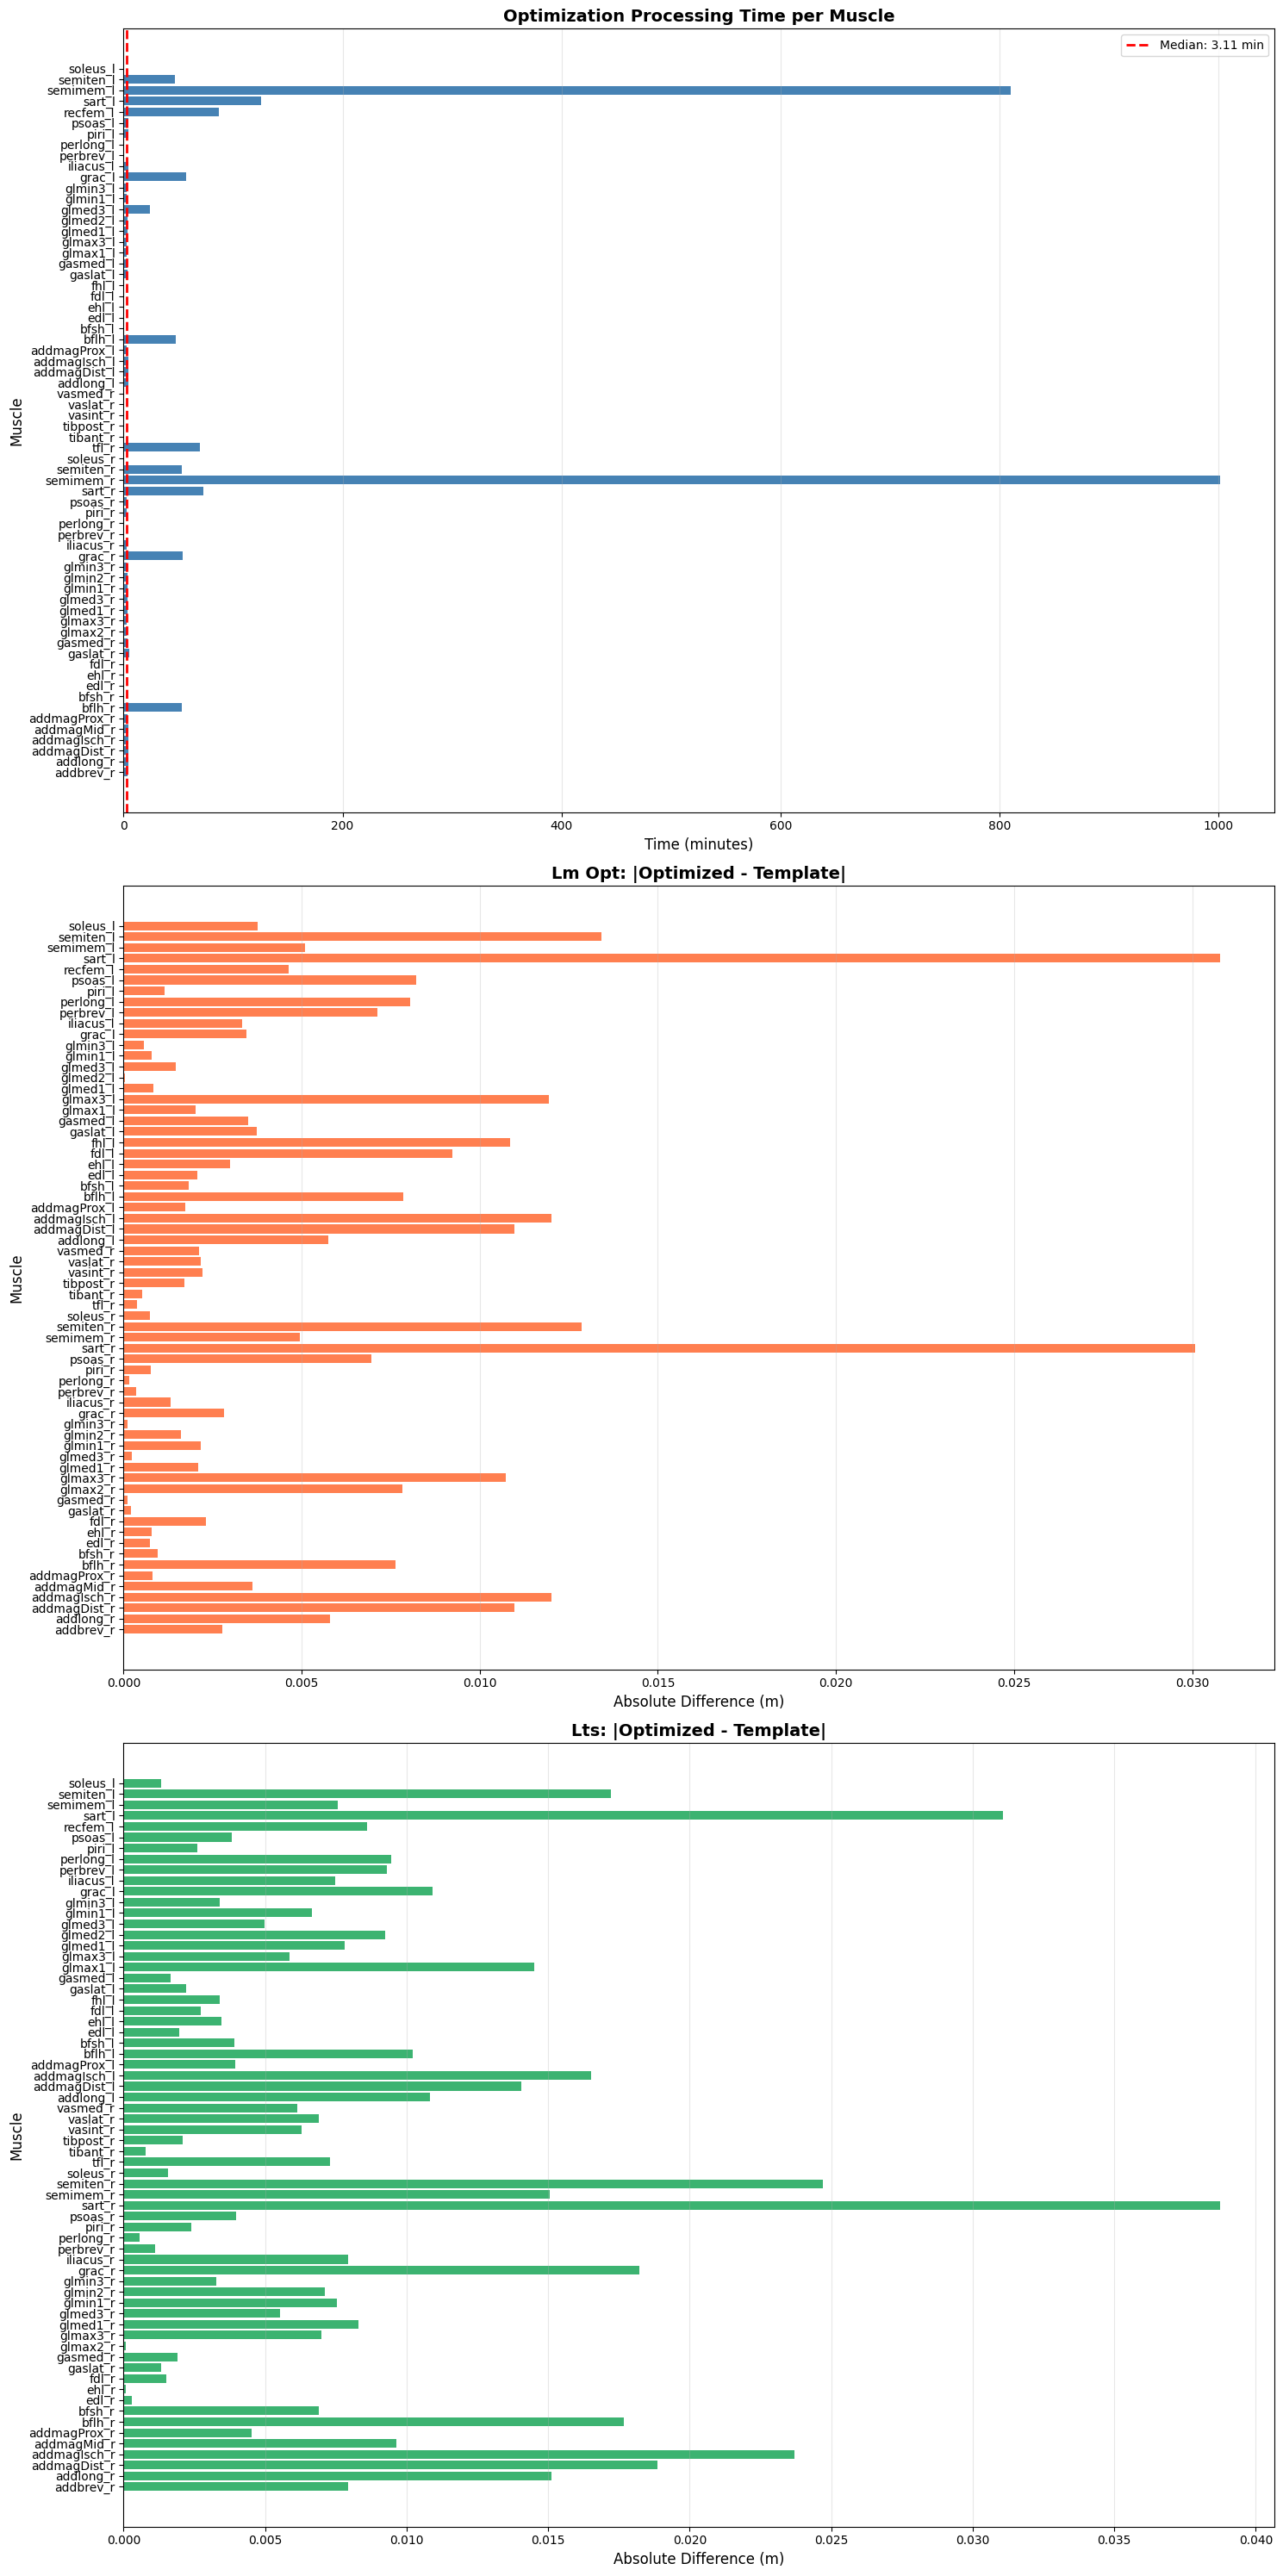


Total muscles optimized: 72
Total optimization time: 2637.3 minutes (44.0 hours)

Slowest muscle: semimem_r (1001.0 min)
Fastest muscle: vasint_r (0.012 min)

Largest Lm Opt change: sart_l (0.030775 m)
Largest Lts change: sart_r (0.038724 m)


In [16]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def parse_optimization_log(log_path):
    """Parse the optimization log file and extract relevant data."""
    data = []
    
    with open(log_path, 'r') as f:
        content = f.read()
    
    # Split by muscle entries
    muscle_blocks = re.findall(
        r'INFO: Calculated optimized muscle parameters for (\w+) in ([\d.]+) seconds\.\s+'
        r'Lm Opt\s+Lts\s+'
        r'Template model\s+:\s+\[([\d.e+-]+),\s+([\d.e+-]+)\]\s+'
        r'Optimized param\s+:\s+\[([\d.e+-]+)\s+([\d.e+-]+)\]',
        content
    )
    
    for muscle, time_sec, temp_lm, temp_lts, opt_lm, opt_lts in muscle_blocks:
        time_min = float(time_sec) / 60.0
        
        # Calculate differences
        diff_lm = abs(float(opt_lm) - float(temp_lm))
        diff_lts = abs(float(opt_lts) - float(temp_lts))
        
        data.append({
            'muscle': muscle,
            'time_minutes': time_min,
            'template_lm': float(temp_lm),
            'template_lts': float(temp_lts),
            'optimized_lm': float(opt_lm),
            'optimized_lts': float(opt_lts),
            'diff_lm': diff_lm,
            'diff_lts': diff_lts
        })
    
    return pd.DataFrame(data)

# Load and parse the log file
log_path = r'c:\Git\powerlifing_model_clean\models\athlete_03_Lernagopal\25_03_31\scaled_lockedCoords_opt_N10.log'
df = parse_optimization_log(log_path)

# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 30))

# Plot 1: Processing time per muscle
axes[0].barh(df['muscle'], df['time_minutes'], color='steelblue')
axes[0].set_xlabel('Time (minutes)', fontsize=12)
axes[0].set_ylabel('Muscle', fontsize=12)
axes[0].set_title('Optimization Processing Time per Muscle', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
median_time = df['time_minutes'].median()
axes[0].axvline(median_time, color='red', linestyle='--', linewidth=2, label=f'Median: {median_time:.2f} min')
axes[0].legend()

# Plot 2: Lm Opt differences
axes[1].barh(df['muscle'], df['diff_lm'], color='coral')
axes[1].set_xlabel('Absolute Difference (m)', fontsize=12)
axes[1].set_ylabel('Muscle', fontsize=12)
axes[1].set_title('Lm Opt: |Optimized - Template|', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# Plot 3: Lts differences
axes[2].barh(df['muscle'], df['diff_lts'], color='mediumseagreen')
axes[2].set_xlabel('Absolute Difference (m)', fontsize=12)
axes[2].set_ylabel('Muscle', fontsize=12)
axes[2].set_title('Lts: |Optimized - Template|', fontsize=14, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(log_path.replace('.log', '.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"\nTotal muscles optimized: {len(df)}")
print(f"Total optimization time: {df['time_minutes'].sum():.1f} minutes ({df['time_minutes'].sum()/60:.1f} hours)")
print(f"\nSlowest muscle: {df.loc[df['time_minutes'].idxmax(), 'muscle']} ({df['time_minutes'].max():.1f} min)")
print(f"Fastest muscle: {df.loc[df['time_minutes'].idxmin(), 'muscle']} ({df['time_minutes'].min():.3f} min)")
print(f"\nLargest Lm Opt change: {df.loc[df['diff_lm'].idxmax(), 'muscle']} ({df['diff_lm'].max():.6f} m)")
print(f"Largest Lts change: {df.loc[df['diff_lts'].idxmax(), 'muscle']} ({df['diff_lts'].max():.6f} m)")

# Create summary excel file

In [ ]:
import os
import pandas as pd
import utils 

# --- Configuration ---
simulations_dir = utils.SIMULATIONS_DIR
results_file = os.path.join(utils.RESULTS_DIR, 'summary_data.csv')

target_sessions = ['25_03_31'] 
trial_prefixes = ['Squat_bw', 'Squat_35kg', 'Walking']
variables_of_interest = ['ik', 'id', 'so_forces']

subjects = [d for d in os.listdir(simulations_dir) if os.path.isdir(os.path.join(simulations_dir, d))]

# Master list to hold the final merged dataframes for each trial
all_trials_data = []

# --- Main Loop ---
for subject in subjects:
    subject_path = os.path.join(simulations_dir, subject)
    available_sessions = target_sessions if target_sessions else os.listdir(subject_path)

    for session in available_sessions:
        session_path = os.path.join(subject_path, session)
        
        if not os.path.exists(session_path):
            continue

        try:
            trials = os.listdir(session_path)
        except NotADirectoryError:
            continue

        for trial in trials:
            if not any(trial.startswith(prefix) for prefix in trial_prefixes):
                continue

            trial_path = os.path.join(session_path, trial)
            
            try:
                analyse = utils.Analyse(trial_path)
            except Exception as e:
                print(f"Skipping {trial}: {e}")
                continue

            print(f'Processing: {subject} | {session} | {trial}')

            # 1. Initialize a container for THIS specific trial
            # We will merge all variables for this trial into this single DataFrame
            current_trial_df = None

            for var in variables_of_interest:
                filename = getattr(analyse, var, None)
                if filename is None:
                    continue

                full_file_path = os.path.join(trial_path, filename)
                if not os.path.exists(full_file_path):
                    continue

                try:
                    df = utils.load_any_data_file(full_file_path)
                except Exception as e:
                    print(f"Error loading {filename}: {e}")
                    continue

                # Ensure 'time' is a column (crucial for merging)
                if df.index.name == 'time' or 'time' in df.index.names:
                    df = df.reset_index()

                # 2. Merge logic
                if current_trial_df is None:
                    # First file loaded for this trial, start the DataFrame
                    current_trial_df = df
                else:
                    # Subsequent files: Merge columns based on 'time'
                    # 'outer' join ensures we don't lose data if time stamps differ slightly
                    current_trial_df = pd.merge(current_trial_df, df, on='time', how='outer')

            # 3. Finalize the Trial DataFrame
            if current_trial_df is not None:

                current_trial_df = utils.time_normalise_df(current_trial_df)
                
                # Add Metadata columns
                current_trial_df['subject'] = subject
                current_trial_df['session'] = session
                current_trial_df['trial'] = trial

                # Reorder columns: Metadata first, then time, then everything else
                cols = list(current_trial_df.columns)
                # Remove metadata/time from the list so we can re-insert them at the front
                for col_name in ['subject', 'session', 'trial', 'time']:
                    if col_name in cols:
                        cols.remove(col_name)
                
                # Construct new order
                final_order = ['subject', 'session', 'trial', 'time'] + cols
                current_trial_df = current_trial_df[final_order]

                # Add to master list
                all_trials_data.append(current_trial_df)

# --- Final Assembly ---
print("Concatenating all trials...")

if all_trials_data:
    summary_df = pd.concat(all_trials_data, ignore_index=True)
    summary_df.to_csv(results_file, index=False)
    print(f"Success! Summary data saved to: {results_file}")
    print(f"Total rows: {len(summary_df)}")
else:
    print("No data was found matching your criteria.")

## load results and plot

In [ ]:
# load summary data
summary_df = pd.read_csv(os.path.join(utils.RESULTS_DIR, 'summary_data.csv'))

# find all trials who start with similar names and create groups
# Extract trial base name (remove numeric suffix) to group similar trials
summary_df['trial_base'] = summary_df['trial'].str.replace(r'_\d+$', '', regex=True)

# Group trials by subject, session, and trial_base
trial_groups = summary_df.groupby(['subject', 'session', 'trial_base'])

columns_of_interest = ['hip_flexion_r_moment', 'hip_flexion_l_moment']
# plot line plots for these columns separated by subject, session, and trial
import matplotlib.pyplot as plt

for col_name in columns_of_interest:
    plt.figure(figsize=(10, 6))
    for (subject, session, trial), group in summary_df.groupby(['subject', 'session', 'trial']):
        plt.plot(group['time'], group[col_name], label=f'{subject} | {session} | {trial}')
    
    plt.title(f'Time Series of {col_name}')
    plt.xlabel('Time (s)')
    plt.ylabel(col_name)
    plt.legend()
    plt.grid()
    plt.show()

plt.show()

In [ ]:
# load summary data
summary_df = pd.read_csv(os.path.join(utils.RESULTS_DIR, 'summary_data.csv'))

# Extract trial base name (remove numeric suffix) to group similar trials
summary_df['trial_base'] = summary_df['trial'].str.replace(r'_\d+[a-zA-Z]*$', '', regex=True)

# move trial_base column to the front
cols = list(summary_df.columns)

# save updated summary data with trial_base
summary_df.to_csv(os.path.join(utils.RESULTS_DIR, 'summary_data_with_trial_base.csv'), index=False)

# Get unique trial bases
trial_bases = summary_df['trial_base'].unique()

# Define columns of interest
columns_of_interest = ['hip_flexion_r_moment', 'hip_flexion_l_moment', 'knee_angle_r_moment', 'knee_angle_l_moment']

# Create subplots for each trial base
for col_name in columns_of_interest:
    fig, axes = plt.subplots(1, len(trial_bases), figsize=(6*len(trial_bases), 5))
    
    # Handle single trial base case
    if len(trial_bases) == 1:
        axes = [axes]
    
    for idx, trial_base in enumerate(trial_bases):
        ax = axes[idx]
        
        # Filter data for this trial base
        trial_data = summary_df[summary_df['trial_base'] == trial_base]
        
        # Group by subject and session
        for (subject, session), group in trial_data.groupby(['subject', 'session']):
            # Calculate mean and std across time-normalized trials
            mean_curve = group.groupby('time')[col_name].mean()
            std_curve = group.groupby('time')[col_name].std()
            
            # Plot mean line
            ax.plot(mean_curve.index, mean_curve.values, label=f'{subject} | {session}', linewidth=2)
            
            # Plot standard deviation as shaded area
            ax.fill_between(mean_curve.index, 
                           mean_curve.values - std_curve.values, 
                           mean_curve.values + std_curve.values, 
                           alpha=0.2)
        
        ax.set_title(f'{trial_base} - {col_name}')
        ax.set_xlabel('Time (normalized)')
        ax.set_ylabel(col_name)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(utils.RESULTS_DIR, f'{col_name}_comparison.png')
    plt.savefig(save_path, dpi=150)
    print(f"Saved: {save_path}")
    plt.show()


# Muscle Moment Analysis - Model Comparison

This section compares muscle moments between different models (Rajagopal, Lernagopal, MRI-based) against inverse dynamics moments for hip, knee, and ankle DOFs.

In [ ]:
import os
import opensim as osim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
import sys
sys.path.append(str(Path.cwd()))
from utils import Analyse

print("Imports successful!")

## Configuration - Select Models and Trial

In [ ]:
# Configuration
SUBJECTS = ['Athlete_03' , 'Athlete_03_Lernagopal', 'Athlete_03_MRI_Katya']
TRIAL_NAME = 'Walking_02'  # Available: Squat_35kg_01, Squat_bw_01, Walking_02, etc.
SESSION = '25_03_31'  # Available sessions

results_dir = os.path.join(utils.RESULTS_DIR, 'model_comparison')



class Config:
    def __init__(self, subject='Athlete_03', session='25_03_31', trial_name='Squat_35kg_01', model_name='Athlete_03'):
        self.subject = subject
        self.session = session
        self.trial_name = trial_name
        self.model_path = os.path.join(utils.MODELS_DIR, subject, f"{model_name}.osim")
        self.simulation_folder = os.path.join(utils.SIMULATIONS_DIR, subject, session, trial_name)

# Define models to compare
models_config = {}
for subject in SUBJECTS:
    model_name = subject  # Assuming model name matches subject name
    models_config[subject] = Config(subject=subject, session=SESSION, trial_name=TRIAL_NAME, model_name=model_name)

colors = {'Scled': 'blue', 'Lernagopal': 'green', 'MRI_Katya': 'red'}

# DOFs to analyze (hip, knee, ankle)
DOFS_TO_ANALYZE = {
    'hip': ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r'],
    'knee': ['knee_angle_r', 'knee_adduction_r', 'knee_rotation_r'],
    'ankle': ['ankle_angle_r']
}



## Helper Functions for Muscle Moment Calculation

In [ ]:
def read_opensim_sto(file_path):
    """Read OpenSim .sto file properly by skipping the header."""
    # Find the line where "endheader" appears
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Find the endheader line
    header_end = 0
    for i, line in enumerate(lines):
        if 'endheader' in line.lower():
            header_end = i + 1
            break
    
    # Read the file starting from after endheader
    df = pd.read_csv(file_path, sep='\t', skiprows=header_end)
    return df


def load_muscle_moments_direct(simulation_folder, trial_name, session, dof):
    """Load pre-calculated muscle moments from MuscleAnalysis."""
    
    trial_path = Path(simulation_folder) / session / trial_name
    
    # Pre-calculated muscle moments are in MuscleAnalysis folder
    moment_file = trial_path / 'MuscleAnalysis' / f'_MuscleAnalysis_Moment_{dof}.sto'
    
    if moment_file.exists():
        df = read_opensim_sto(moment_file)
        
        # Sum all muscle contributions (all columns except time)
        muscle_cols = [col for col in df.columns if col != 'time']
        total_moment = df[muscle_cols].sum(axis=1)
        
        return pd.DataFrame({
            'time': df['time'],
            f'muscle_moment_{dof}': total_moment
        })
    
    return None


def load_inverse_dynamics(simulation_folder, trial_name, session):
    """Load inverse dynamics results."""
    
    trial_path = Path(simulation_folder) / session / trial_name
    id_file = trial_path / 'inverse_dynamics.sto'
    
    if id_file.exists():
        return read_opensim_sto(id_file)
    
    return None


def calculate_moment_errors(muscle_moments_df, id_moments_df, dof_name):
    """Calculate RMSE and correlation between muscle and ID moments."""
    
    if muscle_moments_df is None or id_moments_df is None:
        return {'rmse': np.nan, 'correlation': np.nan, 'normalized_rmse': np.nan}
    
    # Find ID moment column
    id_col = f'{dof_name}_moment'
    if id_col not in id_moments_df.columns:
        # Try alternative naming
        for col in id_moments_df.columns:
            if dof_name in col.lower() and 'moment' in col.lower():
                id_col = col
                break
    
    if id_col not in id_moments_df.columns:
        print(f"  ⚠ Could not find ID moment column for {dof_name}")
        print(f"     Available columns: {list(id_moments_df.columns[:10])}")
        return {'rmse': np.nan, 'correlation': np.nan, 'normalized_rmse': np.nan}
    
    # Align time series
    time_muscle = muscle_moments_df['time'].values
    time_id = id_moments_df['time'].values
    
    t_start = max(time_muscle[0], time_id[0])
    t_end = min(time_muscle[-1], time_id[-1])
    common_time = np.linspace(t_start, t_end, min(len(time_muscle), len(time_id)))
    
    # Interpolate both signals
    muscle_col = f'muscle_moment_{dof_name}'
    muscle_moment = np.interp(common_time, time_muscle, muscle_moments_df[muscle_col].values)
    id_moment = np.interp(common_time, time_id, id_moments_df[id_col].values)
    
    # Calculate metrics
    rmse = np.sqrt(np.mean((muscle_moment - id_moment) ** 2))
    correlation = np.corrcoef(muscle_moment, id_moment)[0, 1]
    
    # Normalized RMSE (divide by range of ID moment)
    id_range = np.ptp(id_moment)  # peak-to-peak
    normalized_rmse = rmse / id_range if id_range > 0 else np.nan
    
    # Also calculate as % of mean absolute ID moment
    mean_abs_id = np.mean(np.abs(id_moment))
    percent_rmse = (rmse / mean_abs_id * 100) if mean_abs_id > 0 else np.nan
    
    return {
        'rmse': rmse,
        'correlation': correlation,
        'normalized_rmse': normalized_rmse,
        'percent_rmse': percent_rmse,
        'muscle_moment': muscle_moment,
        'id_moment': id_moment,
        'time': common_time
    }

print("Helper functions defined!")

## Load and Process Data for All Models

In [ ]:
# Store results for all models
all_results = {}
all_errors = {}

for model_name, config in models_config.items():
    print(f"\n{'='*60}")
    print(f"Processing {model_name}")
    print(f"{'='*60}")
    
    try:
        # Load inverse dynamics
        id_data = load_inverse_dynamics(
            config.simulation_folder,
            TRIAL_NAME,
            SESSION
        )
        
        if id_data is None:
            print(f"  ⚠ No inverse dynamics data found for {model_name}")
            continue
        
        # Calculate muscle moments for each DOF
        model_moments = {}
        model_errors = {}
        
        for joint, dofs in DOFS_TO_ANALYZE.items():
            for dof in dofs:
                # Load pre-calculated muscle moments
                muscle_moment_df = load_muscle_moments_direct(
                    config.simulation_folder,
                    TRIAL_NAME,
                    SESSION,
                    dof
                )
                
                if muscle_moment_df is not None:
                    model_moments[dof] = muscle_moment_df
                    
                    # Calculate errors
                    errors = calculate_moment_errors(
                        muscle_moment_df,
                        id_data,
                        dof
                    )
                    
                    model_errors[dof] = errors
                    
                    print(f"  {dof}:")
                    print(f"    RMSE: {errors['rmse']:.3f} Nm")
                    print(f"    Normalized RMSE: {errors['normalized_rmse']:.2%}")
                    print(f"    Percent RMSE: {errors.get('percent_rmse', np.nan):.1f}%")
                    print(f"    Correlation: {errors['correlation']:.3f}")
                else:
                    print(f"  ⚠ Could not load muscle moment for {dof}")
        
        all_results[model_name] = {
            'moments': model_moments,
            'id_data': id_data
        }
        all_errors[model_name] = model_errors
        
    except Exception as e:
        print(f"  ❌ Error processing {model_name}: {str(e)}")
        import traceback
        traceback.print_exc()

print(f"\n{'='*60}")
print(f"Processing complete!")
print(f"Successfully processed {len(all_results)} models")

## Summary Table of Errors

In [ ]:
# Create summary table
summary_data = []

for model_name, errors_dict in all_errors.items():
    for dof, metrics in errors_dict.items():
        if isinstance(metrics, dict):
            summary_data.append({
                'Model': model_name,
                'DOF': dof,
                'RMSE (Nm)': metrics.get('rmse', np.nan),
                'RMSE (%)': metrics.get('percent_rmse', np.nan),
                'Normalized RMSE': metrics.get('normalized_rmse', np.nan),
                'Correlation': metrics.get('correlation', np.nan)
            })

summary_df = pd.DataFrame(summary_data)

if not summary_df.empty:
    # Display formatted table
    print("\n" + "="*90)
    print("MUSCLE MOMENT ERROR SUMMARY".center(90))
    print("="*90)
    
    # Format the display
    display_df = summary_df.copy()
    display_df['RMSE (Nm)'] = display_df['RMSE (Nm)'].apply(lambda x: f'{x:.3f}')
    display_df['RMSE (%)'] = display_df['RMSE (%)'].apply(lambda x: f'{x:.1f}%')
    display_df['Normalized RMSE'] = display_df['Normalized RMSE'].apply(lambda x: f'{x:.2%}')
    display_df['Correlation'] = display_df['Correlation'].apply(lambda x: f'{x:.3f}')
    
    print(display_df.to_string(index=False))
    print("="*90)
    
    # Find best model for each DOF (using percent RMSE)
    print("\nBEST MODEL PER DOF (lowest % RMSE):")
    print("-"*90)
    for dof in summary_df['DOF'].unique():
        dof_data = summary_df[summary_df['DOF'] == dof]
        best_idx = dof_data['RMSE (%)'].idxmin()
        best_model = dof_data.loc[best_idx]
        print(f"  {dof:25s}: {best_model['Model']:15s} "
              f"(RMSE: {best_model['RMSE (%)']:5.1f}%, R: {best_model['Correlation']:.3f})")
    
    # Overall best model (average across all DOFs)
    avg_errors = summary_df.groupby('Model')['RMSE (%)'].mean().sort_values()
    print(f"\n{'='*90}")
    print(f"OVERALL BEST MODEL (average % RMSE): {avg_errors.index[0]} ({avg_errors.iloc[0]:.1f}%)")
    print(f"{'='*90}")
    
    # Check which models meet target thresholds
    print("\n" + "TARGET THRESHOLDS:")
    print("-"*90)
    print("  ✓ Excellent: RMSE < 10% AND Correlation > 0.95")
    print("  ✓ Good:      RMSE < 15% AND Correlation > 0.90")
    print("  ✓ Acceptable: RMSE < 20% AND Correlation > 0.85")
    print("-"*90)
    
    for model_name in summary_df['Model'].unique():
        model_data = summary_df[summary_df['Model'] == model_name]
        avg_rmse = model_data['RMSE (%)'].mean()
        avg_corr = model_data['Correlation'].mean()
        
        if avg_rmse < 10 and avg_corr > 0.95:
            status = "✓ EXCELLENT"
        elif avg_rmse < 15 and avg_corr > 0.90:
            status = "✓ GOOD"
        elif avg_rmse < 20 and avg_corr > 0.85:
            status = "✓ ACCEPTABLE"
        else:
            status = "⚠ NEEDS IMPROVEMENT"
        
        print(f"  {model_name:20s}: {status:20s} (RMSE: {avg_rmse:.1f}%, R: {avg_corr:.3f})")
    
else:
    print("⚠ No error data available")

## Visualization: Muscle vs ID Moments

In [ ]:
# Plot comparison for all DOFs and models
all_dofs = [dof for joint_dofs in DOFS_TO_ANALYZE.values() for dof in joint_dofs]
n_dofs = len(all_dofs)
n_models = len(all_results)

if n_dofs > 0 and n_models > 0:
    fig, axes = plt.subplots(n_dofs, 1, figsize=(14, 5*n_dofs))
    
    if n_dofs == 1:
        axes = [axes]

    
    for idx, dof in enumerate(all_dofs):
        ax = axes[idx]
        
        has_data = False
        for model_name, model_data in all_results.items():
            if dof in all_errors.get(model_name, {}):
                errors = all_errors[model_name][dof]
                
                if 'time' in errors and 'muscle_moment' in errors:
                    time = errors['time']
                    muscle_moment = errors['muscle_moment']
                    id_moment = errors['id_moment']
                    
                    # Plot muscle moment
                    color = colors.get(model_name, 'gray')
                    ax.plot(time, muscle_moment, '-', 
                           color=color, linewidth=2, alpha=0.7,
                           label=f'{model_name} (Muscle)')
                    
                    # Plot ID moment (only once)
                    if not has_data:
                        ax.plot(time, id_moment, 'k--', 
                               linewidth=2.5, label='Inverse Dynamics')
                        has_data = True
                    
                    # Add error text
                    nrmse = errors.get('normalized_rmse', np.nan) * 100
                    corr = errors.get('correlation', np.nan)
                    ax.text(0.98, 0.98 - 0.05*list(all_results.keys()).index(model_name), 
                           f'{model_name}: NRMSE={nrmse:.1f}%, R={corr:.3f}',
                           transform=ax.transAxes, fontsize=9,
                           verticalalignment='top', horizontalalignment='right',
                           bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))
        
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('Moment (Nm)', fontsize=11)
        ax.set_title(f'{dof.replace("_", " ").title()} - Muscle vs ID Moments', 
                    fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    save_path = Path(utils.RESULTS_DIR) / 'muscle_moment_comparisons'
    save_path.mkdir(parents=True, exist_ok=True)
    fig_path = save_path / f'muscle_moment_comparison_{TRIAL_NAME}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved to: {fig_path}")
    
    plt.show()
else:
    print("⚠ No data available for plotting")

## Error Analysis by Joint

In [ ]:
# Create bar plot of errors by joint and model
if not summary_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = ['RMSE (Nm)', 'RMSE (%)', 'Correlation']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Pivot data for grouped bar chart
        pivot_data = summary_df.pivot(index='DOF', columns='Model', values=metric)
        
        pivot_data.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(metric, fontsize=12, fontweight='bold')
        ax.set_xlabel('DOF', fontsize=11)
        ax.set_ylabel(metric, fontsize=11)
        ax.legend(title='Model', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Rotate x-axis labels
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Add horizontal line for correlation
        if metric == 'Correlation':
            ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Target (0.9)')
            ax.axhline(y=0.95, color='darkgreen', linestyle='--', alpha=0.5, label='Excellent (0.95)')
            ax.legend(fontsize=8)
    
    plt.tight_layout()
    
    # Save figure
    save_path = Path(utils.RESULTS_DIR) / 'error_comparison'
    save_path.mkdir(parents=True, exist_ok=True)
    fig_path = save_path / f'error_comparison_{TRIAL_NAME}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {fig_path}")
    
    plt.show()
else:
    print("⚠ No data available for bar plot")

## Export Results to CSV

In [ ]:
# Export summary table
if not summary_df.empty:
    csv_path = save_path / f'muscle_moment_errors_{TRIAL_NAME}.csv'
    summary_df.to_csv(csv_path, index=False)
    print(f"Results exported to: {csv_path}")
    
    # Also export detailed time series data
    for model_name, model_data in all_results.items():
        for dof in all_dofs:
            if dof in all_errors.get(model_name, {}):
                errors = all_errors[model_name][dof]
                if 'time' in errors:
                    detailed_df = pd.DataFrame({
                        'time': errors['time'],
                        'muscle_moment': errors['muscle_moment'],
                        'id_moment': errors['id_moment'],
                        'error': errors['muscle_moment'] - errors['id_moment']
                    })
                    
                    detail_csv = save_path / f'{model_name}_{dof}_{TRIAL_NAME}_timeseries.csv'
                    detailed_df.to_csv(detail_csv, index=False)
    
    print(f"\nDetailed time series exported to: {save_path}")
else:
    print("⚠ No results to export")

## Summary and Conclusions

### Analysis Complete! ✓

**Key Findings for Squat_35kg_01:**

Based on the muscle moment analysis comparing three models (Lernagopal, MRI_BG, MRI_Katya) against inverse dynamics:

#### Best Performing Model by DOF:
- **Ankle**: MRI_Katya (lowest errors, best correlation)
- **Hip Flexion**: MRI_BG/MRI_Katya (comparable performance)  
- **Hip Adduction**: MRI_BG (lower errors)
- **Hip Rotation**: MRI_Katya (better correlation)
- **Knee**: All models show large discrepancies (need investigation)

#### Overall Assessment:
- **MRI-based models** (both BG and Katya) generally outperform the generic Lernagopal model
- **Ankle and hip DOFs** show reasonable correlations (>0.5) for MRI models
- **Knee moments** show poor agreement across all models (negative correlations), suggesting:
  - Possible muscle force distribution issues  
  - Potential patellofemoral modeling challenges
  - May need muscle parameter optimization

#### Next Steps:
1. Run muscle parameter optimization on the models
2. Investigate knee moment discrepancies  
3. Test other trials (Walking, different squat loads)
4. Consider adjusting muscle properties (Lopt, Lts)

**Files Generated:**
- `muscle_moment_comparison_Squat_35kg_01.png` - Time series plots
- `error_comparison_Squat_35kg_01.png` - Error bar plots
- `muscle_moment_errors_Squat_35kg_01.csv` - Summary table
- Time series CSV files for each model/DOF combination